In [ ]:
import sympy
from sympy import symbols, sin, cos
from sympy import Matrix, nsolve
from sympy.parsing.sympy_parser import parse_expr
from itertools import product

from scipy.optimize import minimize

import multiprocessing
import os
import time
from tqdm import tqdm

import os
os.chdir("//home//rydpi5//serverfolder//expctl//src")

import xarray as xr

from expctl.servers.servoaligner.solver_plotter import Optical_system_solver, Mirror, Lens
from expctl.servers.servoaligner.iteration_actuator import iteration_actuator
from expctl.servers.servoaligner.iterator_compute import angle_calc_single

import numpy as np
import matplotlib.pyplot as plt
import time,pickle
from expctl.servers.servoaligner.scservo_sdk import *                    # Uses SCServo SDK library
from expctl.servers.servoaligner.pts_iterator import pts_iterator
import logging

from smbus2 import SMBus,i2c_msg
import MCP342x

logging.basicConfig(
    level=logging.INFO,  # Set the logging level to DEBUG
    # level= logging.DEBUG,|
    format='%(asctime)s - %(levelname)s - %(message)s'
)

from expctl.servers.servoaligner.servodriver import Servoset
from expctl.servers.servoaligner.servo_util import create_zigzag_X, format_para,a2p,r2nd,r2nr,ndmodr,nrselr,nrmodr,nraddr,compose_para
from expctl.servers.servoaligner.fit_gaussian import gaussian_2d,gaussian_2d_smooth_heaviside,fit_and_plot,fit_gaussian_2d,fit_gaussian_2d_smooth_heaviside,fit_and_plot_smooth_heaviside,popt_get_mu_cov,statistics_skewness
from expctl.servers.servoaligner.motor_scan import motor_1d_scan,motor_2d_scan
from expctl.servers.servoaligner.servo_const import A_X_XDOT_MASK,A_Y_YDOT_MASK,A_X_Y_MASK,A_XDOT_YDOT_MASK,A_POS_ALL_MASK,B_X_XDOT_MASK,B_Y_YDOT_MASK,B_X_Y_MASK,B_XDOT_YDOT_MASK,B_POS_ALL_MASK,POS_ALL_MASK, posmask2str
#from expctl.servers.servoaligner.pd import MCP3424_fiber
from expctl.servers.servoaligner.step_optimize import step_optimize

In [27]:
servos = Servoset(board_id=0,servo_channel_list=[0,1,2,3,4,5,6,7])

i2cbus = SMBus(1)
MCP3424_fiber=MCP342x.MCP342x(i2cbus, 0x68, device='MCP3424', channel=0, gain=1, resolution=12, continuous_mode=False, scale_factor=1.0, offset=0.0)

2025-03-06 17:15:39,464 - INFO - Succeeded to open the port
2025-03-06 17:15:39,467 - INFO - Succeeded to change the baudrate
2025-03-06 17:15:39,473 - INFO - Servo 1x: SCServo acc set!
2025-03-06 17:15:39,479 - INFO - Servo 1x: SCServo speed set!
2025-03-06 17:15:39,485 - INFO - Servo 1x: SCServo acc set!
2025-03-06 17:15:39,491 - INFO - Servo 1x: SCServo speed set!
2025-03-06 17:15:39,501 - INFO - Servo 1y: SCServo acc set!
2025-03-06 17:15:39,506 - INFO - Servo 1y: SCServo speed set!
2025-03-06 17:15:39,511 - INFO - Servo 1y: SCServo acc set!
2025-03-06 17:15:39,516 - INFO - Servo 1y: SCServo speed set!
2025-03-06 17:15:39,525 - INFO - Servo 2x: SCServo acc set!
2025-03-06 17:15:39,530 - INFO - Servo 2x: SCServo speed set!
2025-03-06 17:15:39,535 - INFO - Servo 2x: SCServo acc set!
2025-03-06 17:15:39,540 - INFO - Servo 2x: SCServo speed set!
2025-03-06 17:15:39,549 - INFO - Servo 2y: SCServo acc set!
2025-03-06 17:15:39,554 - INFO - Servo 2y: SCServo speed set!
2025-03-06 17:15:39,

In [5]:
servos.home()
servos.torques_disable()

2025-03-07 14:23:11,883 - INFO - going home


In [ ]:
servos.set_zero()

2025-03-03 17:54:06,389 - INFO - Setting Zero
2025-03-03 17:54:06,401 - INFO - Servo 1x: SCServo zero set!
2025-03-03 17:54:06,437 - INFO - [TxRxResult] There is no status packet!
2025-03-03 17:54:06,472 - INFO - Servo 1y: result [TxRxResult] Incorrect status packet!
2025-03-03 17:54:06,473 - INFO - Servo 1y: SCServo zero set!
2025-03-03 17:54:06,484 - INFO - Servo 2x: SCServo zero set!
2025-03-03 17:54:06,495 - INFO - Servo 2y: SCServo zero set!
2025-03-03 17:54:06,531 - INFO - [TxRxResult] There is no status packet!
2025-03-03 17:54:06,537 - ERROR - Servo 3x: Read not sucessful!
2025-03-03 17:54:06,573 - INFO - Servo 3x: result [TxRxResult] Incorrect status packet!
2025-03-03 17:54:06,574 - INFO - Servo 3x: SCServo zero set!
2025-03-03 17:54:06,609 - INFO - [TxRxResult] There is no status packet!
2025-03-03 17:54:06,615 - ERROR - Servo 3y: Read not sucessful!
2025-03-03 17:54:06,621 - ERROR - Servo 3y: Read not sucessful!
2025-03-03 17:54:06,657 - INFO - Servo 3y: result [TxRxResult]

In [12]:
#servos.set_zero()
servos.torques_disable()

In [6]:
servos.home()
print(MCP3424_fiber.convert_and_read())

2025-03-07 14:23:15,959 - INFO - going home


1.044


In [11]:
print(MCP3424_fiber.convert_and_read())
servos.get_angle()

1.04


array([-0.43945312, -0.43945312, -0.43945312, -0.61523438,  0.        ,
        0.        ,  0.        ,  0.        ])

# Angle sweeping

In [2]:
from itertools import product

import multiprocessing
import os
import time
from tqdm import tqdm

import os
os.chdir("//home//rydpi5//serverfolder//expctl//src")

import xarray as xr

from expctl.servers.servoaligner.solver_plotter_np import Optical_system_solver, Mirror, Lens
from expctl.servers.servoaligner.iteration_actuator import iteration_actuator, single_actuator_minimize
from expctl.servers.servoaligner.iterator_compute import angle_calc_single, scan_xarray_gen, scan_xarray_gen_knobs

from scipy.optimize import minimize

import numpy as np
import matplotlib.pyplot as plt
import time,pickle
from expctl.servers.servoaligner.scservo_sdk import *                    # Uses SCServo SDK library
from expctl.servers.servoaligner.pts_iterator import pts_iterator
import logging

from functools import partial

from smbus2 import SMBus,i2c_msg
import MCP342x

logging.basicConfig(
    level=logging.INFO,  # Set the logging level to DEBUG
    # level= logging.DEBUG,|
    format='%(asctime)s - %(levelname)s - %(message)s'
)

from expctl.servers.servoaligner.servodriver import Servoset

In [3]:
servos = Servoset(board_id=0,servo_channel_list=[0,1,2,3,4,5,6,7])
i2cbus = SMBus(1)
MCP3424_fiber=MCP342x.MCP342x(i2cbus, 0x68, device='MCP3424', channel=0, gain=1, resolution=12, continuous_mode=False, scale_factor=1.0, offset=0.0)

2025-03-07 10:48:50,186 - INFO - Succeeded to open the port
2025-03-07 10:48:50,189 - INFO - Succeeded to change the baudrate
2025-03-07 10:48:50,194 - INFO - Servo 1x: SCServo acc set!
2025-03-07 10:48:50,200 - INFO - Servo 1x: SCServo speed set!
2025-03-07 10:48:50,205 - INFO - Servo 1x: SCServo acc set!
2025-03-07 10:48:50,210 - INFO - Servo 1x: SCServo speed set!
2025-03-07 10:48:50,219 - INFO - Servo 1y: SCServo acc set!
2025-03-07 10:48:50,224 - INFO - Servo 1y: SCServo speed set!
2025-03-07 10:48:50,229 - INFO - Servo 1y: SCServo acc set!
2025-03-07 10:48:50,234 - INFO - Servo 1y: SCServo speed set!
2025-03-07 10:48:50,243 - INFO - Servo 2x: SCServo acc set!
2025-03-07 10:48:50,248 - INFO - Servo 2x: SCServo speed set!
2025-03-07 10:48:50,253 - INFO - Servo 2x: SCServo acc set!
2025-03-07 10:48:50,258 - INFO - Servo 2x: SCServo speed set!
2025-03-07 10:48:50,267 - INFO - Servo 2y: SCServo acc set!
2025-03-07 10:48:50,272 - INFO - Servo 2y: SCServo speed set!
2025-03-07 10:48:50,

In [1]:
#mirror spacing
x1 = 0.155
x2 = 0.27
x3 = 0.14
x4 = 0.15
#lens spacing
dy0 = 0.36
dy1 = 0.16
#focal length
fl1 = 0.205
fl2 = 0.145
fl3 = 1
#MOT and Cavity
MOT_pos_1=0
Cav_pos_1=-2e-4

MOT_pos_2=0
Cav_pos_2=2e-4

MOT_pos_rel = 0.22
MOT_Cav_dist = -0.044

params={'x1':x1, 'x2':x2, 'x3': x3, 'x4':x4, 'dy0':dy0, 'dy1':dy1, 'fl1': fl1, 'fl2': fl2, 'fl3': fl3, 'MOT_pos_rel': MOT_pos_rel, 'MOT_Cav_dist': MOT_Cav_dist, 'MOT_pos_1': MOT_pos_1, 'Cav_pos_1': Cav_pos_1, 'MOT_pos_2': MOT_pos_2, 'Cav_pos_2': Cav_pos_2}

In [2]:
solver_0=Optical_system_solver()
#scan_xr=scan_xarray_gen(var_str_list=['fl1','fl2','MOT_pos_1','MOT_pos_2'], range_list=[1e-2, 1e-2, 2e-4, 2e-4], num_list=[5,5,10,10], start_value_list=[fl1, MOT_pos_1, MOT_pos_2])
#scan_xr=scan_xarray_gen(solver_0, var_str_list=['fl1','MOT_pos_rel','Cav_pos_1'], range_list=[1e-2, 4e-2, 4e-4], num_list=[5,20,20], start_value_list=[fl1, MOT_pos_rel, Cav_pos_1], params=params)
#scan_xr=scan_xarray_gen(solver_0, var_str_list=['MOT_pos_rel','Cav_pos_2'], range_list=[4e-2, 4e-4], num_list=[20,20], start_value_list=[MOT_pos_rel, Cav_pos_2], params=params)
#scan_xr=scan_xarray_gen(solver_0, var_str_list=['MOT_pos_rel','Cav_pos_1','Cav_pos_2'], range_list=[2e-2, 1e-3, 1e-3], num_list=[5,10,10], start_value_list=[MOT_pos_rel,Cav_pos_1, Cav_pos_2], params=params)
scan_xr=scan_xarray_gen(solver_0, var_str_list=['fl1','fl2','Cav_pos_1','Cav_pos_2'], range_list=[1e-2, 1e-2, 4e-4, 4e-4], num_list=[5,5,10,10], start_value_list=[fl1, fl2, Cav_pos_1, Cav_pos_2], params=params)
#scan_xr=scan_xarray_gen(solver_0, var_str_list=['dy0','MOT_pos_rel','Cav_pos_1','Cav_pos_2'], range_list=[2e-2, 2e-2, 4e-4, 4e-4], num_list=[5,5,10,10], start_value_list=[dy0,MOT_pos_rel,Cav_pos_1, Cav_pos_2], params=params)
scan_xr

NameError: name 'Optical_system_solver' is not defined

In [101]:
ds=iteration_actuator(servos, MCP3424_fiber, scan_xr)

100%|██████████| 2500/2500 [45:48<00:00,  1.10s/it] 
2025-03-06 16:32:53,077 - INFO - going home


1.04


In [103]:
ds

<xarray.Dataset>
Dimensions:      (fl1: 5, fl2: 5, Cav_pos_1: 10, Cav_pos_2: 10, knobs: 8)
Coordinates:
  * fl1          (fl1) float64 0.19 0.195 0.2 0.205 0.21
  * fl2          (fl2) float64 0.14 0.145 0.15 0.155 0.16
  * Cav_pos_1    (Cav_pos_1) float64 -0.0004 -0.0003111 ... 0.0003111 0.0004
  * Cav_pos_2    (Cav_pos_2) float64 -0.0004 -0.0003111 ... 0.0003111 0.0004
  * knobs        (knobs) <U6 'Mrr1_x' 'Mrr1_y' 'Mrr2_x' ... 'Mrr4_x' 'Mrr4_y'
Data variables:
    knob_angles  (fl1, fl2, Cav_pos_1, Cav_pos_2, knobs) float64 -280.3 ... -...
    data         (fl1, fl2, Cav_pos_1, Cav_pos_2) float64 0.033 0.037 ... 0.001

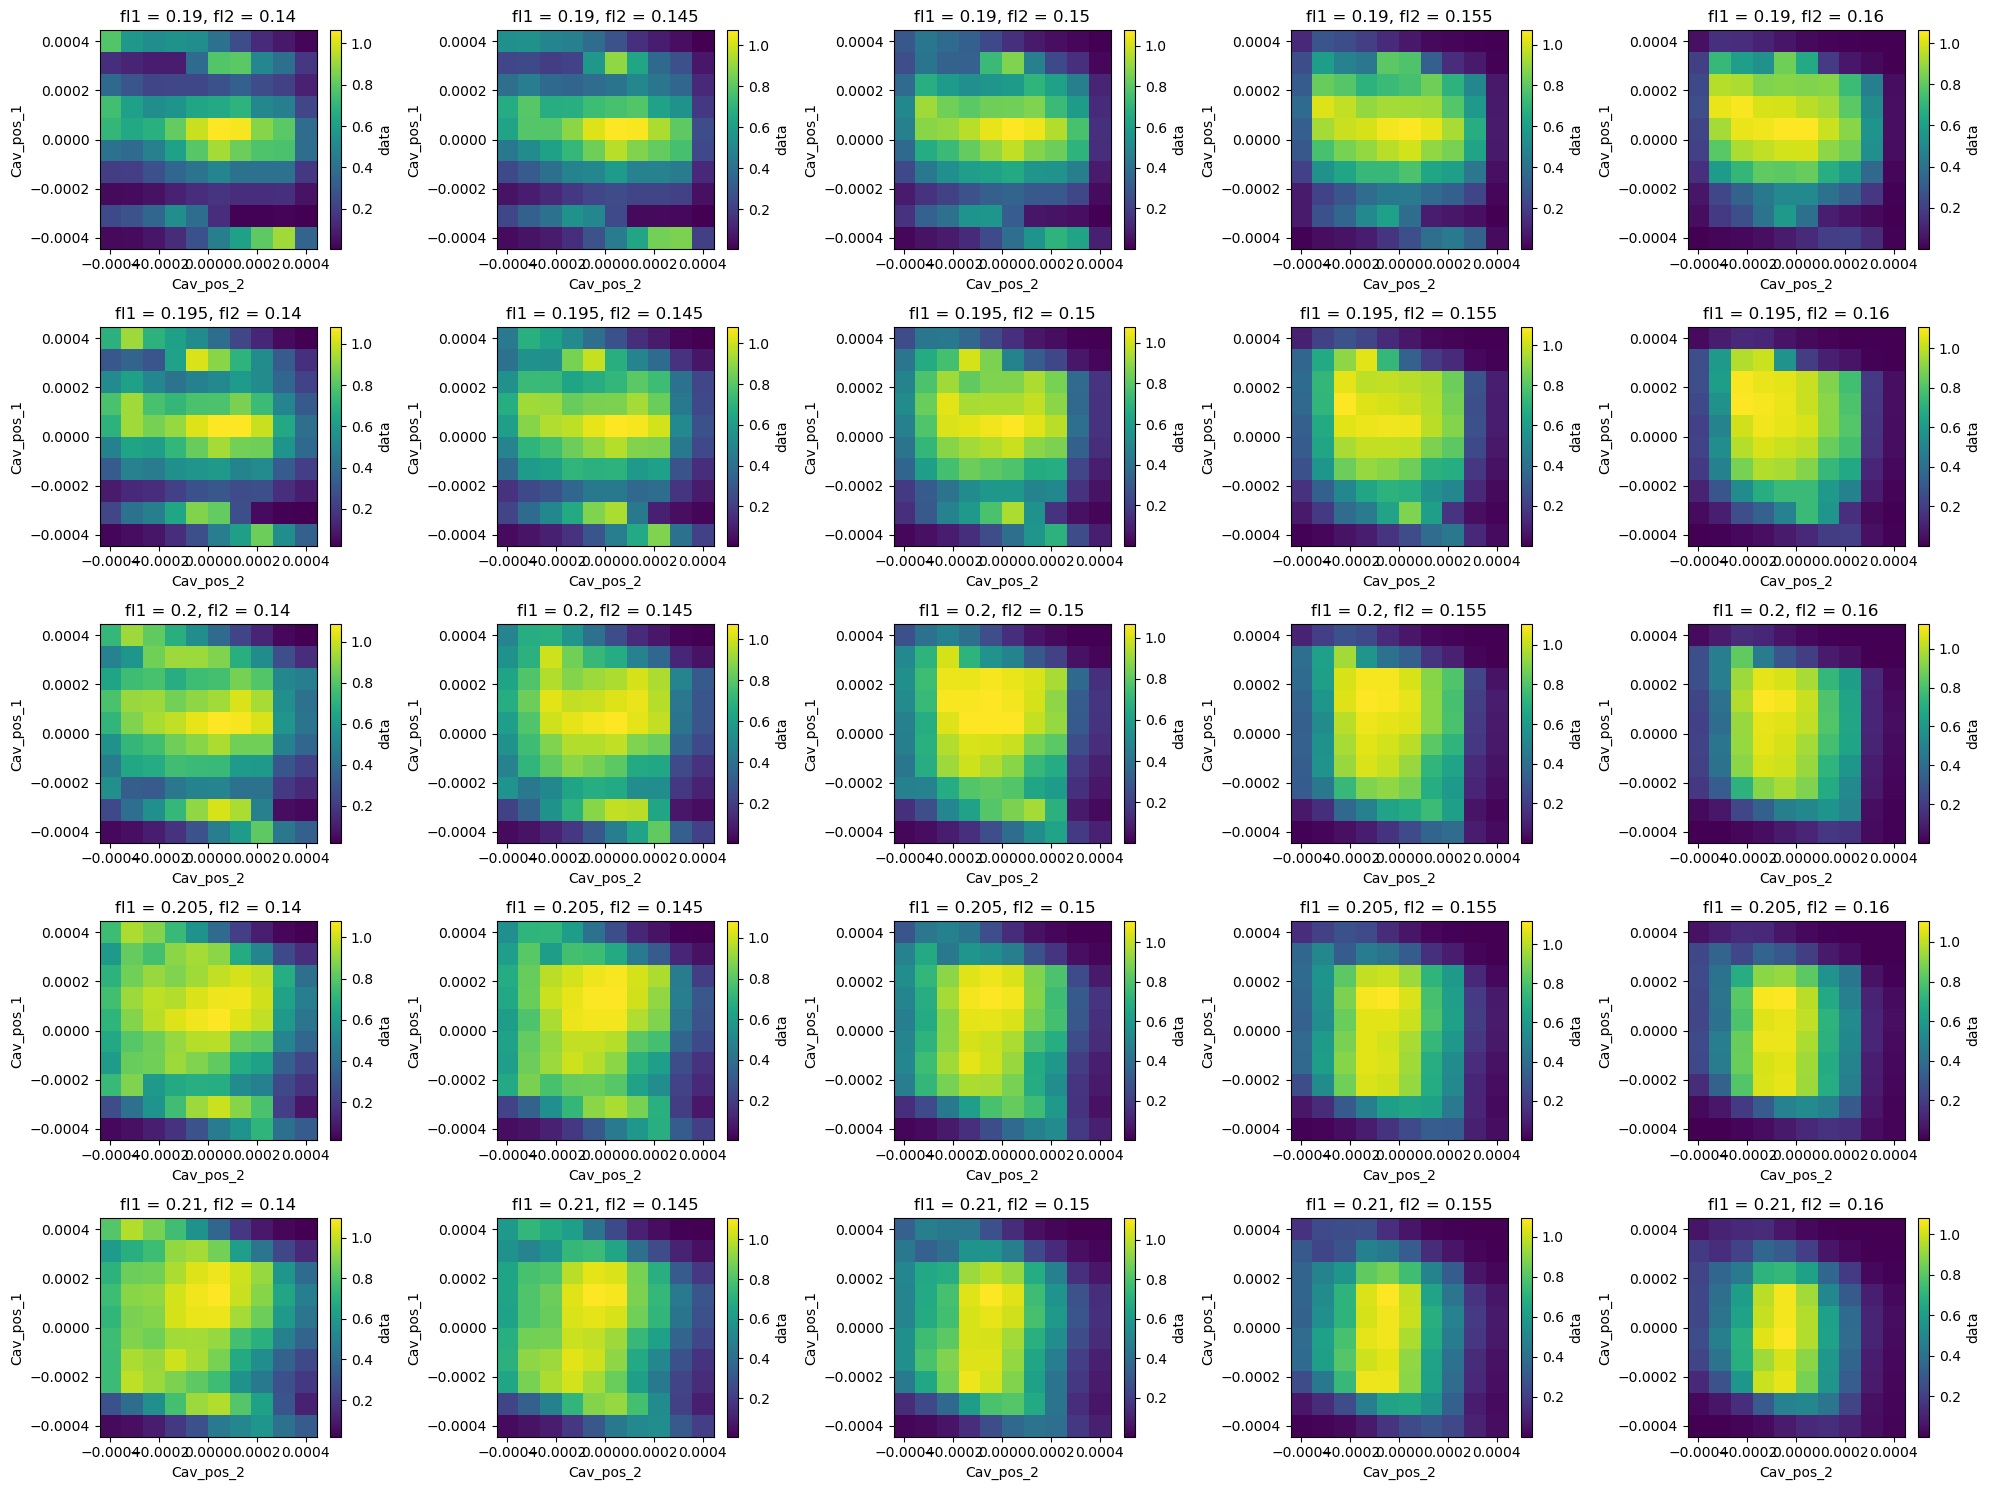

In [102]:
fig,axs=plt.subplots(5,5,figsize=(20,15)) 
for i in range(5):
    for j in range(5):
        ds['data'].isel(fl1=i, fl2=j).plot(ax=axs[i,j])
fig.tight_layout()
plt.show()

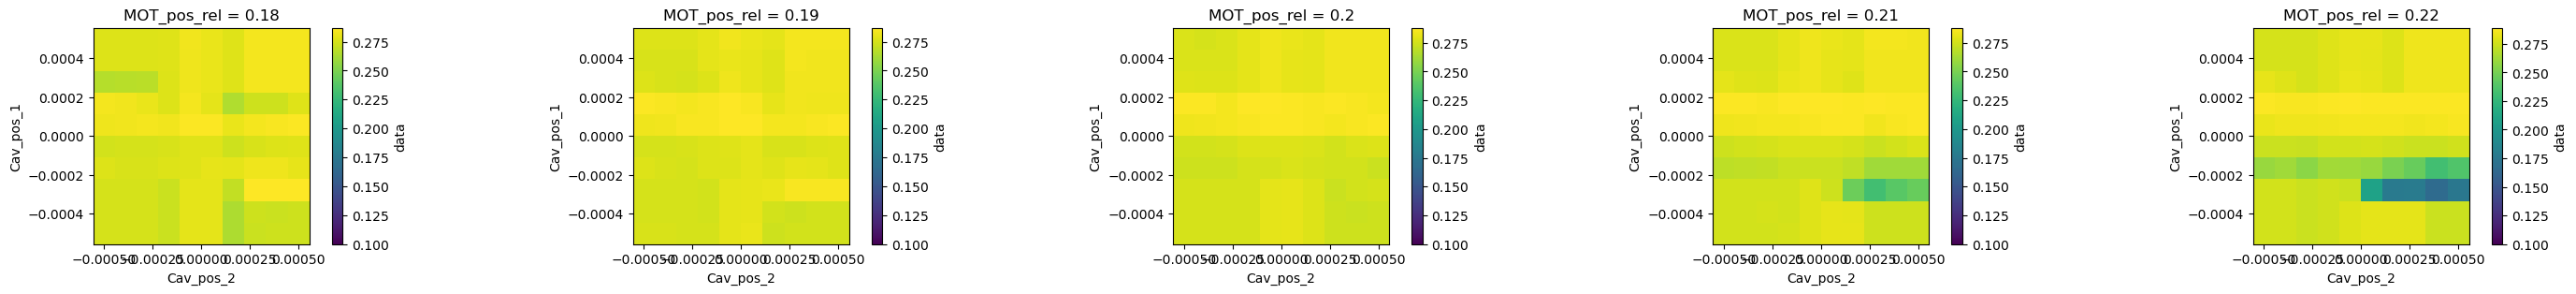

In [75]:
fig,axs=plt.subplots(1,5,figsize=(36,3)) 
for i in range(5):
    ds['data'].isel(MOT_pos_rel=i).plot(ax=axs[i], vmin=0.10)
    axs[i].set_aspect('equal')
#fig.tight_layout()
plt.show()

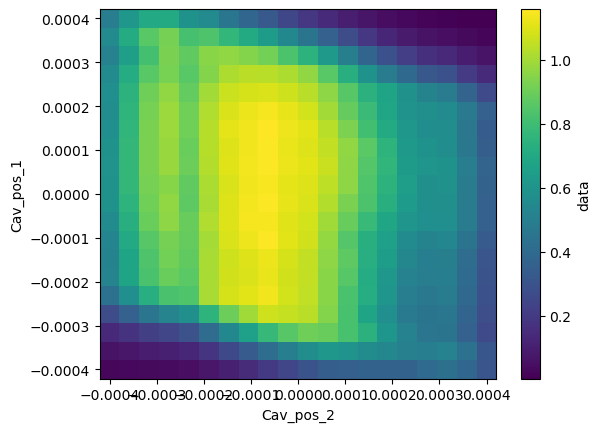

In [15]:
ds['data'].plot()

In [29]:
ds.to_netcdf("data0306_1.nc")

In [ ]:
ds=xr.open_dataset("data0304_3.nc")
ds['data'].plot()

In [149]:
#mirror spacing
x1 = 0.155
x2 = 0.27
x3 = 0.14
x4 = 0.15
#lens spacing
dy0 = 0.36
dy1 = 0.16
#focal length
fl1 = 0.2
fl2 = 0.15
fl3 = 1
#MOT and Cavity
MOT_pos_1=0
Cav_pos_1=-5e-4

MOT_pos_2=0
Cav_pos_2=0

MOT_pos_rel = 0.20
MOT_Cav_dist = -0.044

params={'x1':x1, 'x2':x2, 'x3': x3, 'x4':x4, 'dy0':dy0, 'dy1':dy1, 'fl1': fl1, 'fl2': fl2, 'fl3': fl3, 'MOT_pos_rel': MOT_pos_rel, 'MOT_Cav_dist': MOT_Cav_dist, 'MOT_pos_1': MOT_pos_1, 'Cav_pos_1': Cav_pos_1, 'MOT_pos_2': MOT_pos_2, 'Cav_pos_2': Cav_pos_2}

knob_deg_list=angle_calc_single(params)
print(knob_deg_list)

servos.set_angle(knob_deg_list)
print('fiber power:',MCP3424_fiber.convert_and_read())

solver_0=Optical_system_solver()
scan_xr_knob=scan_xarray_gen_knobs(solver_0, var_str_list=['servo_3x','servo_4x'], range_list=[50,50], offset_list=[-50,-50], num_list=[20,20], knob_deg_list=knob_deg_list)

scan_xr_knob

[-343.5067891076635, 0.0, -343.50678886894315, 0.0, -187.54489013927883, 0.0, -244.98237181993755, 0.0]
fiber power: 0.005


<xarray.DataArray (servo_3x: 20, servo_4x: 20, knobs: 8)>
array([[[-343.50678911,    0.        , -343.50678887, ...,
            0.        , -344.98237182,    0.        ],
        [-343.50678911,    0.        , -343.50678887, ...,
            0.        , -339.71921393,    0.        ],
        [-343.50678911,    0.        , -343.50678887, ...,
            0.        , -334.45605603,    0.        ],
        ...,
        [-343.50678911,    0.        , -343.50678887, ...,
            0.        , -255.50868761,    0.        ],
        [-343.50678911,    0.        , -343.50678887, ...,
            0.        , -250.24552971,    0.        ],
        [-343.50678911,    0.        , -343.50678887, ...,
            0.        , -244.98237182,    0.        ]],

       [[-343.50678911,    0.        , -343.50678887, ...,
            0.        , -344.98237182,    0.        ],
        [-343.50678911,    0.        , -343.50678887, ...,
            0.        , -339.71921393,    0.        ],
        [-343.50678911,    0.        , -343.50678887, ...,
            0.        , -334.45605603,    0.        ],
...
        [-343.50678911,    0.        , -343.50678887, ...,
            0.        , -255.50868761,    0.        ],
        [-343.50678911,    0.        , -343.50678887, ...,
            0.        , -250.24552971,    0.        ],
        [-343.50678911,    0.        , -343.50678887, ...,
            0.        , -244.98237182,    0.        ]],

       [[-343.50678911,    0.        , -343.50678887, ...,
            0.        , -344.98237182,    0.        ],
        [-343.50678911,    0.        , -343.50678887, ...,
            0.        , -339.71921393,    0.        ],
        [-343.50678911,    0.        , -343.50678887, ...,
            0.        , -334.45605603,    0.        ],
        ...,
        [-343.50678911,    0.        , -343.50678887, ...,
            0.        , -255.50868761,    0.        ],
        [-343.50678911,    0.        , -343.50678887, ...,
            0.        , -250.24552971,    0.        ],
        [-343.50678911,    0.        , -343.50678887, ...,
            0.        , -244.98237182,    0.        ]]])
Coordinates:
  * servo_3x  (servo_3x) float64 -287.5 -282.3 -277.0 ... -198.1 -192.8 -187.5
  * servo_4x  (servo_4x) float64 -345.0 -339.7 -334.5 ... -255.5 -250.2 -245.0
  * knobs     (knobs) <U6 'Mrr1_x' 'Mrr1_y' 'Mrr2_x' ... 'Mrr4_x' 'Mrr4_y'

In [5]:
ds_knob=iteration_actuator(servos, MCP3424_fiber, scan_xr_knob)

100%|██████████| 400/400 [02:00<00:00,  3.33it/s]
2025-03-06 17:32:53,314 - INFO - going home


1.035


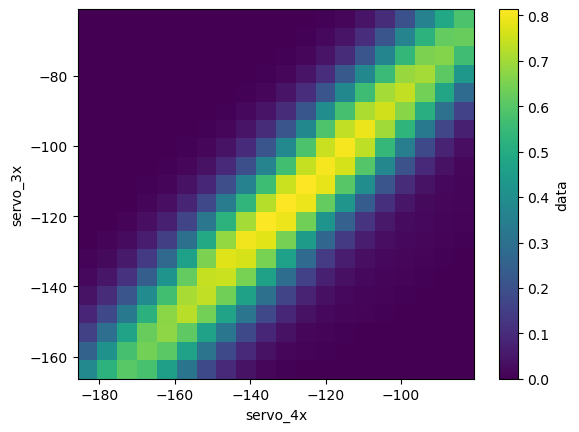

In [6]:
ds_knob['data'].plot()

In [19]:
knob_deg_list=[-116.6010304545216, 137.33043067108903, -116.60102852809291, -137.33042837948153, -121, 61.4985211137023, -134, -84.47311247400913]
servos.set_angle(knob_deg_list)
print('fiber power:',MCP3424_fiber.convert_and_read())

solver_0=Optical_system_solver()
scan_xr_knob=scan_xarray_gen_knobs(solver_0, var_str_list=['servo_3y','servo_4y'], range_list=[50,50], offset_list=[0,0], num_list=[20,20], knob_deg_list=knob_deg_list)

scan_xr_knob

fiber power: 0.8270000000000001


<xarray.DataArray (servo_3y: 20, servo_4y: 20, knobs: 8)>
array([[[-116.60103045,  137.33043067, -116.60102853, ...,
           11.49852111, -134.        , -134.47311247],
        [-116.60103045,  137.33043067, -116.60102853, ...,
           11.49852111, -134.        , -129.20995458],
        [-116.60103045,  137.33043067, -116.60102853, ...,
           11.49852111, -134.        , -123.94679668],
        ...,
        [-116.60103045,  137.33043067, -116.60102853, ...,
           11.49852111, -134.        ,  -44.99942826],
        [-116.60103045,  137.33043067, -116.60102853, ...,
           11.49852111, -134.        ,  -39.73627037],
        [-116.60103045,  137.33043067, -116.60102853, ...,
           11.49852111, -134.        ,  -34.47311247]],

       [[-116.60103045,  137.33043067, -116.60102853, ...,
           16.76167901, -134.        , -134.47311247],
        [-116.60103045,  137.33043067, -116.60102853, ...,
           16.76167901, -134.        , -129.20995458],
        [-116.60103045,  137.33043067, -116.60102853, ...,
           16.76167901, -134.        , -123.94679668],
...
        [-116.60103045,  137.33043067, -116.60102853, ...,
          106.23536322, -134.        ,  -44.99942826],
        [-116.60103045,  137.33043067, -116.60102853, ...,
          106.23536322, -134.        ,  -39.73627037],
        [-116.60103045,  137.33043067, -116.60102853, ...,
          106.23536322, -134.        ,  -34.47311247]],

       [[-116.60103045,  137.33043067, -116.60102853, ...,
          111.49852111, -134.        , -134.47311247],
        [-116.60103045,  137.33043067, -116.60102853, ...,
          111.49852111, -134.        , -129.20995458],
        [-116.60103045,  137.33043067, -116.60102853, ...,
          111.49852111, -134.        , -123.94679668],
        ...,
        [-116.60103045,  137.33043067, -116.60102853, ...,
          111.49852111, -134.        ,  -44.99942826],
        [-116.60103045,  137.33043067, -116.60102853, ...,
          111.49852111, -134.        ,  -39.73627037],
        [-116.60103045,  137.33043067, -116.60102853, ...,
          111.49852111, -134.        ,  -34.47311247]]])
Coordinates:
  * servo_3y  (servo_3y) float64 11.5 16.76 22.02 27.29 ... 101.0 106.2 111.5
  * servo_4y  (servo_4y) float64 -134.5 -129.2 -123.9 ... -45.0 -39.74 -34.47
  * knobs     (knobs) <U6 'Mrr1_x' 'Mrr1_y' 'Mrr2_x' ... 'Mrr4_x' 'Mrr4_y'

In [20]:
ds_knob=iteration_actuator(servos, MCP3424_fiber, scan_xr_knob)

100%|██████████| 400/400 [01:54<00:00,  3.49it/s]
2025-03-06 17:45:30,470 - INFO - going home


1.039


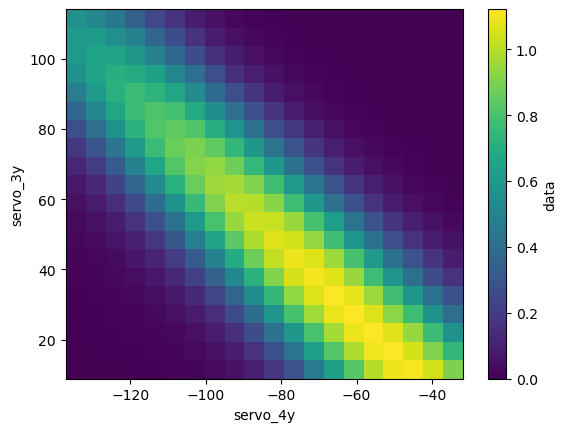

In [21]:
ds_knob['data'].plot()

minimizer

In [ ]:
from itertools import product

import multiprocessing
import os
import time
from tqdm import tqdm

import os
os.chdir("//home//rydpi5//serverfolder//expctl//src")

import xarray as xr

from expctl.servers.servoaligner.solver_plotter_np import Optical_system_solver, Mirror, Lens
from expctl.servers.servoaligner.iteration_actuator import iteration_actuator, actuator_minimize
from expctl.servers.servoaligner.iterator_compute import angle_calc_single, scan_xarray_gen, scan_xarray_gen_knobs

from scipy.optimize import minimize

import numpy as np
import matplotlib.pyplot as plt
import time,pickle
from expctl.servers.servoaligner.scservo_sdk import *                    # Uses SCServo SDK library
from expctl.servers.servoaligner.pts_iterator import pts_iterator
import logging

from functools import partial

from smbus2 import SMBus,i2c_msg
import MCP342x

logging.basicConfig(
    level=logging.INFO,  # Set the logging level to DEBUG
    # level= logging.DEBUG,|
    format='%(asctime)s - %(levelname)s - %(message)s'
)

from expctl.servers.servoaligner.servodriver import Servoset

In [ ]:
servos = Servoset(board_id=0,servo_channel_list=[0,1,2,3,4,5,6,7])
i2cbus = SMBus(1)
MCP3424_fiber=MCP342x.MCP342x(i2cbus, 0x68, device='MCP3424', channel=0, gain=1, resolution=12, continuous_mode=False, scale_factor=1.0, offset=0.0)

2025-03-07 15:38:22,041 - INFO - Succeeded to open the port
2025-03-07 15:38:22,044 - INFO - Succeeded to change the baudrate
2025-03-07 15:38:22,050 - INFO - Servo 1x: SCServo acc set!
2025-03-07 15:38:22,055 - INFO - Servo 1x: SCServo speed set!
2025-03-07 15:38:22,061 - INFO - Servo 1x: SCServo acc set!
2025-03-07 15:38:22,066 - INFO - Servo 1x: SCServo speed set!
2025-03-07 15:38:22,075 - INFO - Servo 1y: SCServo acc set!
2025-03-07 15:38:22,080 - INFO - Servo 1y: SCServo speed set!
2025-03-07 15:38:22,085 - INFO - Servo 1y: SCServo acc set!
2025-03-07 15:38:22,090 - INFO - Servo 1y: SCServo speed set!
2025-03-07 15:38:22,099 - INFO - Servo 2x: SCServo acc set!
2025-03-07 15:38:22,104 - INFO - Servo 2x: SCServo speed set!
2025-03-07 15:38:22,109 - INFO - Servo 2x: SCServo acc set!
2025-03-07 15:38:22,114 - INFO - Servo 2x: SCServo speed set!
2025-03-07 15:38:22,123 - INFO - Servo 2y: SCServo acc set!
2025-03-07 15:38:22,128 - INFO - Servo 2y: SCServo speed set!
2025-03-07 15:38:22,

In [6]:
servos.home()
#print(MCP3424_fiber.convert_and_read())

2025-03-07 15:38:25,713 - INFO - going home


In [4]:
#mirror spacing
x1 = 0.155
x2 = 0.27
x3 = 0.14
x4 = 0.15
#lens spacing
dy0 = 0.36
dy1 = 0.16
#focal length
fl1 = 0.2
fl2 = 0.15
fl3 = 1
#MOT and Cavity
MOT_pos_1=0
Cav_pos_1=3e-4

MOT_pos_2=0
Cav_pos_2=3e-4

MOT_pos_rel = 0.20
MOT_Cav_dist = -0.044

params={'x1':x1, 'x2':x2, 'x3': x3, 'x4':x4, 'dy0':dy0, 'dy1':dy1, 'fl1': fl1, 'fl2': fl2, 'fl3': fl3, 'MOT_pos_rel': MOT_pos_rel, 'MOT_Cav_dist': MOT_Cav_dist, 'MOT_pos_1': MOT_pos_1, 'Cav_pos_1': Cav_pos_1, 'MOT_pos_2': MOT_pos_2, 'Cav_pos_2': Cav_pos_2}

knob_deg_list=angle_calc_single(params)
print(knob_deg_list)

servos.set_angle(knob_deg_list)
print('fiber power:',MCP3424_fiber.convert_and_read())

[236.7304371518977, 206.06235716855468, 236.73035532806932, -206.06232362862133, 129.23462338260086, 92.26598114049317, 168.8928895564789, -126.72791937392036]
fiber power: 0.25


In [4]:
result_deg_list = actuator_minimize(servos, MCP3424_fiber, knob_deg_list)

-0.273
-0.20730000000000004
-0.3886
-0.4673999999999999
-0.6218
-0.6868
-0.7034
-0.7560999999999999
-0.28300000000000003
-0.182
-0.7873
-0.9153
-0.9810000000000001
-0.7897000000000001
-0.9484000000000001
-0.8774
-0.9885000000000002
-0.7653999999999999
-1.0187
-0.9773
-1.0031
-0.9835
-1.0065
Optimization terminated successfully.
         Current function value: -1.018700
         Iterations: 12
         Function evaluations: 23
-1.0145
-0.9481000000000002
-0.9816999999999998
-1.0133000000000003
-1.068
-1.0812000000000002
-0.9114000000000001
-1.0548
-1.1034000000000002
-1.1042
-1.0788999999999997
-1.0995000000000001
-1.0595
-1.1001999999999998
-1.1059999999999999
-1.0802
-1.0715999999999997
-1.1088
-1.0984000000000003
-1.1103
Optimization terminated successfully.
         Current function value: -1.110300
         Iterations: 10
         Function evaluations: 20


In [151]:
# func=partial(single_actuator_minimize, servos=servos, MCP3424_fiber=MCP3424_fiber, servos_name_list=['servo_3x','servo_4x'], knob_deg_list=knob_deg_list)

points = []
values = []

# def wrapper(x):
#     val = single_actuator_minimize(deg_list=x, servos=servos, MCP3424_fiber=MCP3424_fiber, servos_name_list=['servo_3x','servo_4x'], knob_deg_list=knob_deg_list)
#     points.append(x)
#     values.append(val)
#     return val

def wrapper_x(par, knob_deg_list):

    x = par[0]
    y = par[1]
    val = single_actuator_minimize(deg_list=diag_forw(x,y), servos=servos, MCP3424_fiber=MCP3424_fiber, servos_name_list=['servo_3x','servo_4x'], knob_deg_list=knob_deg_list)
    points.append(par)
    values.append(val)
    return val

def wrapper_y(par, knob_deg_list):
    print(knob_deg_list)
    x = par[0]
    y = par[1]
    val = single_actuator_minimize(deg_list=anti_forw(x,y), servos=servos, MCP3424_fiber=MCP3424_fiber, servos_name_list=['servo_3y','servo_4y'], knob_deg_list=knob_deg_list)
    points.append(par)
    values.append(val)
    return val


# minimize(func, [-100, -100], method='Nelder-Mead', bounds=[(-180, 180), (-180, 180)], callback=cb,
#          options={'xatol': 5e-1, 'fatol': 1e-1, 'disp': True, 'maxiter': 50})

# minimize(wrapper, [0, 0], method='Nelder-Mead', bounds=[(-180, 180), (-180, 180)], callback=cb,
#          options={'xatol': 5e-1, 'fatol': 1e-2, 'disp': True, 'maxiter': 50})

# minimize(wrapper, [0, 0], method='CG', bounds=[(-180, 180), (-180, 180)], callback=cb,
#          options={'eps': 10.0, 'disp': True, 'maxiter': 50})

# minimize(wrapper, [0, 0], method='BFGS', bounds=[(-180, 180), (-180, 180)],
#          options={'xrtol': 1e-2, 'eps': 2.0, 'disp': True, 'maxiter': 50})

# minimize(wrapper, [0, 0], method='COBYLA', bounds=[(-180, 180), (-180, 180)],
#          options={'f_target': -0.8, 'feasibility_tol': 0.05, 'initial_tr_radius': 3.0, 'disp': True, 'maxiter': 50})

# res = direct(wrapper, bounds=[(-180, 180), (-180, 180)], eps=0.05, f_min= -0.8, f_min_rtol=0.05, maxiter=50)
# res = direct(wrapper, bounds=[(-180, 180), (-40, 40)], eps=0.05, f_min= -0.8, f_min_rtol=0.05, maxiter=50)

#initial_simplex: array_like of shape (N + 1, N)
initial_simplex = np.array([[0, 0], [10, 0], [0, 3]])

# res = minimize(wrapper_x, [0, 0], method='Nelder-Mead', bounds=[(-180, 180), (-40, 40)],
#          options={'initial_simplex': initial_simplex, 'xatol': 5.0, 'fatol': 1e-1, 'disp': True, 'maxiter': 20})

res = minimize(wrapper_x, [0, 0], method='Nelder-Mead', bounds=[(-180, 180), (-40, 40)], args=(knob_deg_list),
         options={'initial_simplex': initial_simplex, 'xatol': 5.0, 'fatol': 1e-1, 'disp': True, 'maxiter': 20})

# print('fiber power:',MCP3424_fiber.convert_and_read())

-0.012
-0.009999999999999998
-0.022
-0.030000000000000006
-0.05890000000000001
-0.12910000000000005
-0.3479
-0.6109000000000001
-0.9418
-0.4431
-0.0637
-0.7732
-0.40630000000000005
-0.7091999999999998
-0.7209999999999999
-0.8251000000000002
-0.9882
-1.0436999999999999
-0.9469000000000001
-0.9367000000000001
-0.958
-0.9433
-0.9762999999999998
-1.0492
-1.0609
-1.0876
-1.0533000000000001
-1.0339
-1.0725
-1.0718
-1.0802999999999998
-1.0788000000000002
-1.0857
-1.0825
-1.0859
Optimization terminated successfully.
         Current function value: -1.087600
         Iterations: 18
         Function evaluations: 35


In [119]:
servos.get_angle()

array([-117.0703125 ,  136.84570312, -117.0703125 , -137.8125    ,
       -111.4453125 ,   61.43554688, -125.68359375,  -84.55078125])

In [132]:
servos_dict={'servo_1x':0, 'servo_1y':1, 'servo_2x':2, 'servo_2y':3, 'servo_3x':4, 'servo_3y':5, 'servo_4x':6, 'servo_4y':7}

knob_angles_postx = knob_deg_list.copy()
knob_angles_postx[servos_dict['servo_3x']] += diag_forw(*res.x)[0] #res.x[0]-res.x[1]
knob_angles_postx[servos_dict['servo_4x']] += diag_forw(*res.x)[1]

In [133]:
knob_angles_postx

[226.39187287286552,
 137.33043067108903,
 226.39180541166849,
 -137.33042837948153,
 75.72839336234449,
 61.4985211137023,
 100.62219669695605,
 -84.47311247400913]

In [135]:
servos.set_angle(knob_angles_postx)
print('fiber power:',MCP3424_fiber.convert_and_read())

fiber power: 0.999


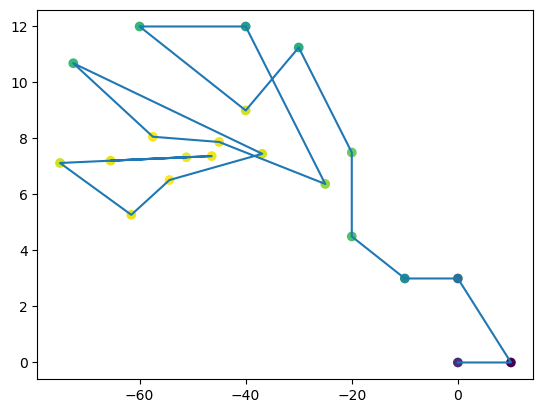

In [134]:
pts = np.stack(points)
vals = np.stack(values)
plt.figure()
plt.plot(pts[:, 0], pts[:,1])
plt.scatter(pts[:, 0], pts[:,1], c=-vals)

In [136]:
res_y = minimize(wrapper_y, [0, 0], method='Nelder-Mead', bounds=[(-180, 180), (-40, 40)], args=(knob_angles_postx),
         options={'initial_simplex': initial_simplex, 'xatol': 5.0, 'fatol': 1e-1, 'disp': True, 'maxiter': 20})

[226.39187287286552, 137.33043067108903, 226.39180541166849, -137.33042837948153, 75.72839336234449, 61.4985211137023, 100.62219669695605, -84.47311247400913]
-0.9993000000000002
[226.39187287286552, 137.33043067108903, 226.39180541166849, -137.33042837948153, 75.72839336234449, 61.4985211137023, 100.62219669695605, -84.47311247400913]
-1.0247
[226.39187287286552, 137.33043067108903, 226.39180541166849, -137.33042837948153, 75.72839336234449, 61.4985211137023, 100.62219669695605, -84.47311247400913]
-0.9295
[226.39187287286552, 137.33043067108903, 226.39180541166849, -137.33042837948153, 75.72839336234449, 61.4985211137023, 100.62219669695605, -84.47311247400913]
-1.0333
[226.39187287286552, 137.33043067108903, 226.39180541166849, -137.33042837948153, 75.72839336234449, 61.4985211137023, 100.62219669695605, -84.47311247400913]
-0.8939999999999999
[226.39187287286552, 137.33043067108903, 226.39180541166849, -137.33042837948153, 75.72839336234449, 61.4985211137023, 100.62219669695605, -8

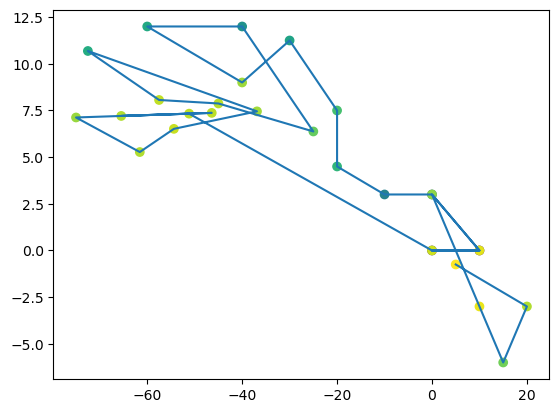

In [137]:
pts = np.stack(points)
vals = np.stack(values)
plt.figure()
plt.plot(pts[:, 0], pts[:,1])
plt.scatter(pts[:, 0], pts[:,1], c=-vals)

In [144]:
knob_angles_posty = knob_angles_postx.copy()
knob_angles_posty[servos_dict['servo_3y']] += anti_forw(*res_y.x)[0] #res.x[0]-res.x[1]
knob_angles_posty[servos_dict['servo_4y']] += anti_forw(*res_y.x)[1]

In [146]:
servos.set_angle(knob_angles_posty)
print('fiber power:',MCP3424_fiber.convert_and_read())

fiber power: 1.052


# Real Setup

In [1]:
from itertools import product

import multiprocessing
import os
import time
from tqdm import tqdm

import os
os.chdir("//home//rydpi5//serverfolder//expctl//src")

import xarray as xr

from expctl.servers.servoaligner.solver_plotter import Optical_system_solver, Mirror, Lens
from expctl.servers.servoaligner.iteration_actuator_cam import iteration_actuator, actuator_minimize, centroid, fitgaussian, gaussian
from expctl.servers.servoaligner.iterator_compute import angle_calc_single, scan_xarray_gen, scan_xarray_gen_knobs

from scipy.optimize import minimize
from picamera2 import Picamera2

import numpy as np
import matplotlib.pyplot as plt
import time,pickle
from expctl.servers.servoaligner.scservo_sdk import *                    # Uses SCServo SDK library
from expctl.servers.servoaligner.pts_iterator import pts_iterator
import logging

from functools import partial

logging.basicConfig(
    level=logging.INFO,  # Set the logging level to DEBUG
    # level= logging.DEBUG,|
    format='%(asctime)s - %(levelname)s - %(message)s'
)

from expctl.servers.servoaligner.servodriver import Servoset

In [2]:
#numerical values
#-----------------------------------------------------
#plane 1
#-----------------------------------------------------
#mirror spacing
x1 = 0.15
x2 = 0.15
x3 = 0.15
x4 = 0.15
#lens spacing
dy0 = 0.1
dy1 = 0.4
dy2 = 0.15
dy3 = 0.15
#focal length
fl1 = 0.2
fl2 = 0.15
fl3 = 1
#MOT and Cavity
MOT_pos_1=1e-3
Cav_pos_1=-1e-3

MOT_pos_2=5e-4
Cav_pos_2=-5e-4

MOT_pos_rel = 0.2

MOT_Cav_dist = 0.04

params={'x1':x1, 'x2':x2, 'x3': x3, 'x4':x4, 'dy0':dy0, 'dy1':dy1, 'dy2': dy2, 'dy3': dy3, 'fl1': fl1, 'fl2': fl2, 'fl3': fl3, 'MOT_Cav_dist': MOT_Cav_dist, 'MOT_pos_rel': MOT_pos_rel, 'MOT_pos_1': MOT_pos_1, 'Cav_pos_1': Cav_pos_1, 'MOT_pos_2': MOT_pos_2, 'Cav_pos_2': Cav_pos_2}

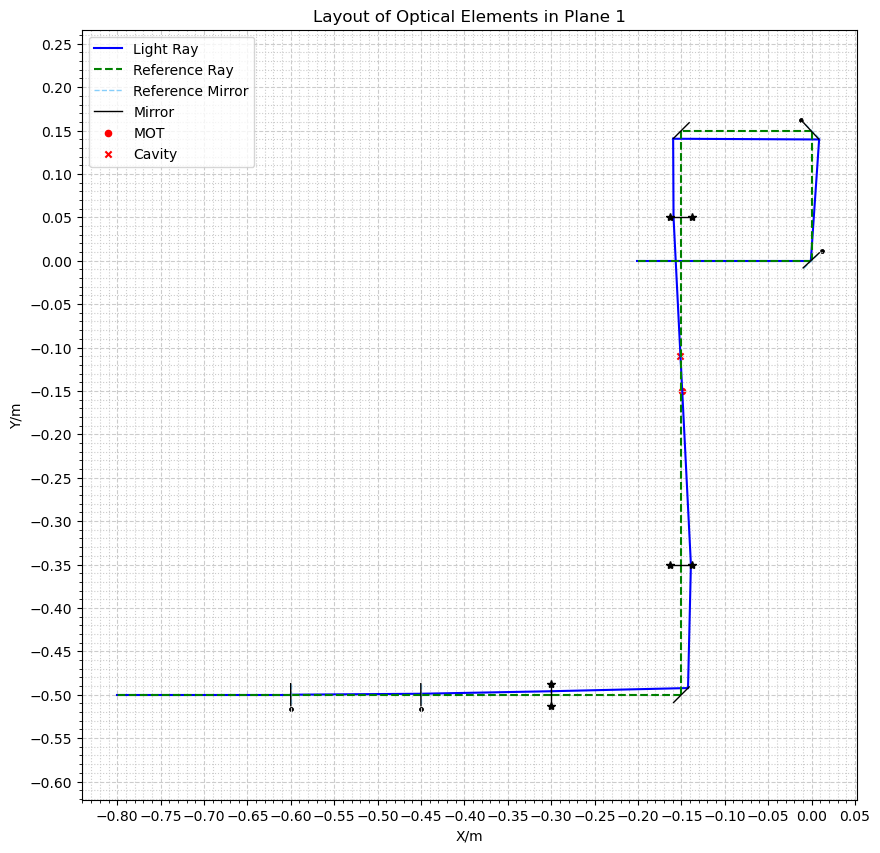

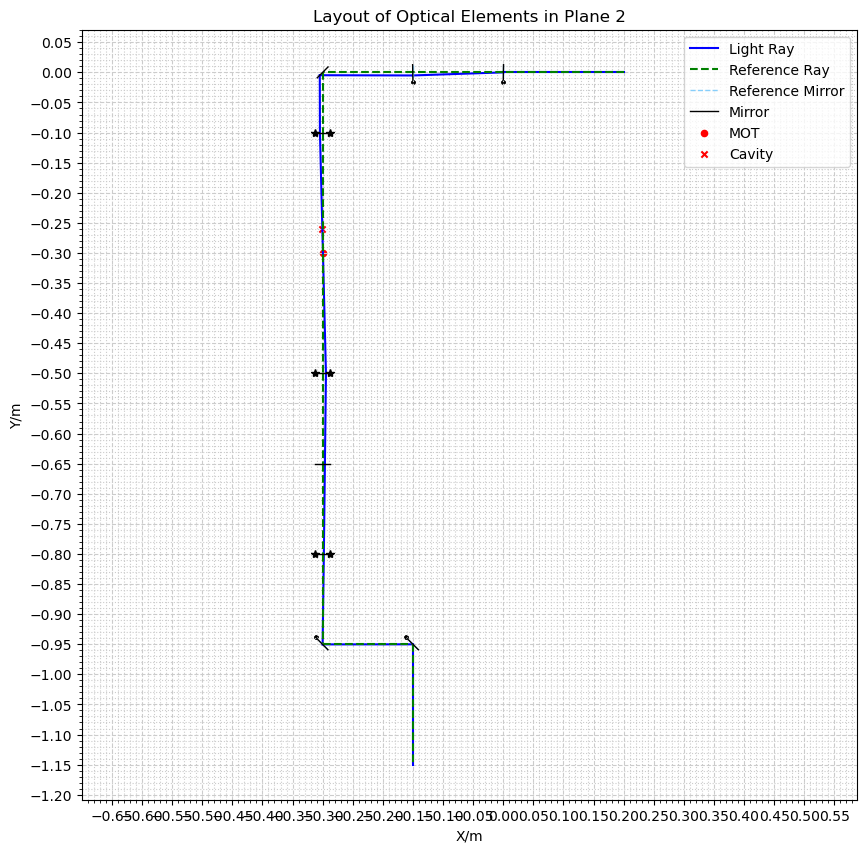

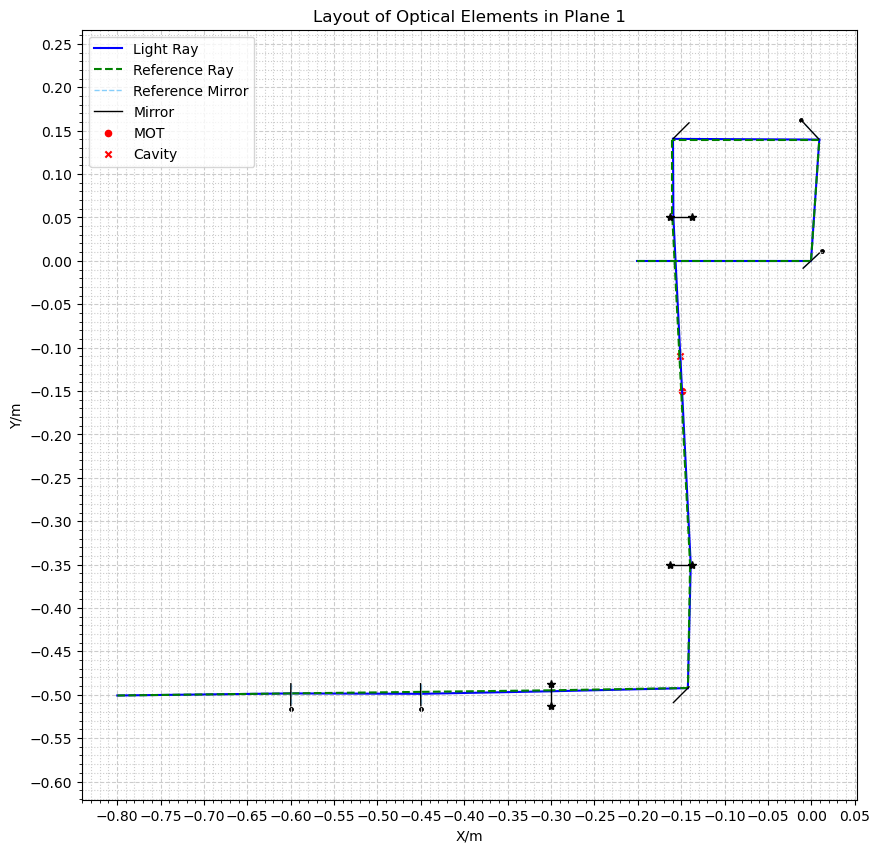

-1596.099696473221
-1713.2450385743514
-520.868696740545
347.461797927811
796.5901095331836
-855.1082117652678
-303.01981809241425
16.764508720417506


In [4]:
%matplotlib inline
solver_0=Optical_system_solver()
solver_1=Optical_system_solver()
solver_2=Optical_system_solver()
solver_0.init_ray_length=0.2
solver_1.init_ray_length=0.2
solver_2.init_ray_length=0.2

solver_0.xy=0
solver_1.xy=1
solver_2.xy=0

solver_0.plot_size=(10,10)
solver_1.plot_size=(10,10)
solver_1.plot_size=(10,10)

Mrr1_1, Mrr2_1, Mrr3_1, Mrr4_1 = solver_0.real_setup_solver_1(params=params, tl_list=[0, 0, 0, 0], comp_list=[0, 0, 0, 0], plot_switch=1)
Mrr1_2, Mrr2_2, Mrr3_2, Mrr4_2 = solver_1.real_setup_solver_2(params=params, tl_list=[0, 0, 0, 0], comp_list=[0, 0, Mrr3_1.tl, Mrr4_1.tl], plot_switch=1)
Mrr1_1c, Mrr2_1c, Mrr3_1c, Mrr4_1c = solver_0.real_setup_solver_1(params=params, tl_list=[Mrr1_1.tl, Mrr1_1.tl, 0, 0], comp_list=[Mrr1_2.tl, Mrr1_2.tl, 0, 0], plot_switch=1)

Mrr_list=[Mrr1_1c, Mrr2_1c, Mrr3_1c, Mrr4_1c, Mrr1_2, Mrr2_2, Mrr3_2, Mrr4_2]
for Mrr in Mrr_list:
    print(Mrr.knob_deg())

# Camera Function

In [1]:
from itertools import product

import multiprocessing
import os
import time
from tqdm import tqdm

import os
os.chdir("//home//rydpi5//serverfolder//expctl//src")

import xarray as xr

from expctl.servers.servoaligner.solver_plotter_np import Optical_system_solver, Mirror, Lens
from expctl.servers.servoaligner.iteration_actuator_cam import iteration_actuator, actuator_minimize, centroid, fitgaussian, gaussian
from expctl.servers.servoaligner.iterator_compute import angle_calc_single, scan_xarray_gen, scan_xarray_gen_knobs

from scipy.optimize import minimize
from picamera2 import Picamera2

import numpy as np
import matplotlib.pyplot as plt
import time,pickle
from expctl.servers.servoaligner.scservo_sdk import *                    # Uses SCServo SDK library
from expctl.servers.servoaligner.pts_iterator import pts_iterator
import logging

from functools import partial

logging.basicConfig(
    level=logging.INFO,  # Set the logging level to DEBUG
    # level= logging.DEBUG,|
    format='%(asctime)s - %(levelname)s - %(message)s'
)

from expctl.servers.servoaligner.servodriver import Servoset

In [2]:
servos = Servoset(board_id=0,servo_channel_list=[0,1,2,3,4,5,6,7])
servos.home()

picam2 = Picamera2()
camera_config = picam2.create_preview_configuration()
camera_config["main"]["size"] = (int(4056//4), int(3040//4))

picam2.configure(camera_config)
picam2.set_controls({"ExposureTime": 100})
picam2.start()

2025-03-08 11:48:42,721 - INFO - The device /dev/ttyUSB0 is not available, try next ...
2025-03-08 11:48:42,742 - INFO - Succeeded to open the port
2025-03-08 11:48:42,765 - INFO - Succeeded to change the baudrate
2025-03-08 11:48:42,770 - INFO - Servo 1x: SCServo acc set!
2025-03-08 11:48:42,775 - INFO - Servo 1x: SCServo speed set!
2025-03-08 11:48:42,780 - INFO - Servo 1x: SCServo acc set!
2025-03-08 11:48:42,785 - INFO - Servo 1x: SCServo speed set!
2025-03-08 11:48:42,794 - INFO - Servo 1y: SCServo acc set!
2025-03-08 11:48:42,799 - INFO - Servo 1y: SCServo speed set!
2025-03-08 11:48:42,804 - INFO - Servo 1y: SCServo acc set!
2025-03-08 11:48:42,809 - INFO - Servo 1y: SCServo speed set!
2025-03-08 11:48:42,818 - INFO - Servo 2x: SCServo acc set!
2025-03-08 11:48:42,822 - INFO - Servo 2x: SCServo speed set!
2025-03-08 11:48:42,827 - INFO - Servo 2x: SCServo acc set!
2025-03-08 11:48:42,832 - INFO - Servo 2x: SCServo speed set!
2025-03-08 11:48:42,841 - INFO - Servo 2y: SCServo acc

[Errno 2] could not open port /dev/ttyUSB0: [Errno 2] No such file or directory: '/dev/ttyUSB0'


2025-03-08 11:48:42,926 - INFO - Servo 4y: SCServo acc set!
2025-03-08 11:48:42,931 - INFO - Servo 4y: SCServo speed set!
2025-03-08 11:48:42,936 - INFO - Servo 4y: SCServo acc set!
2025-03-08 11:48:42,941 - INFO - Servo 4y: SCServo speed set!
2025-03-08 11:48:42,946 - INFO - loading position from disk
2025-03-08 11:48:42,947 - INFO - Loaded, the positions are: 
Servo 1x: 2871.5625 deg	Servo 1y: 2824.892578125 deg	Servo 2x: 2927.548828125 deg	Servo 2y: 359.6484375 deg	Servo 3x: 12.48046875 deg	Servo 3y: 41.484375 deg	Servo 4x: -118.125 deg	Servo 4y: 81.123046875 deg	
2025-03-08 11:48:42,947 - INFO - going home
[19:00:31.533025992] [17987]  INFO Camera camera_manager.cpp:327 libcamera v0.4.0+53-29156679
[19:00:31.540476342] [18016]  INFO RPI pisp.cpp:720 libpisp version v1.1.0 e7974a156008 27-01-2025 (21:50:51)
[19:00:31.549740872] [18016]  INFO RPI pisp.cpp:1179 Registered camera /base/axi/pcie@120000/rp1/i2c@88000/imx477@1a to CFE device /dev/media2 and ISP device /dev/media0 using Pi

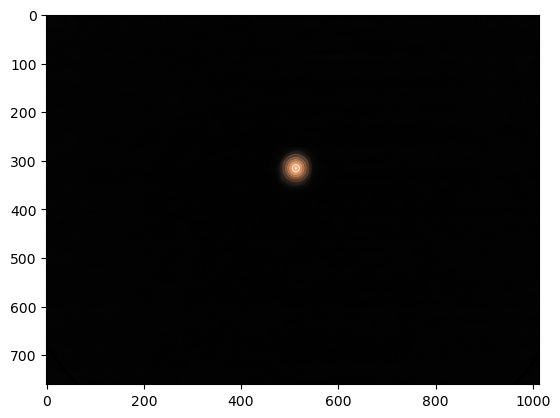

-16.7181634144417 16.07281405075435


In [3]:
#mirror spacing
x1 = 0.155
x2 = 0.27
x3 = 0.14
x4 = 0.15
#lens spacing
dy0 = 0.36
dy1 = 0.16
#focal length
fl1 = 0.205
fl2 = 0.145
fl3 = 1
#MOT and Cavity
MOT_pos_1=0
Cav_pos_1=0

MOT_pos_2=0
Cav_pos_2=0

MOT_pos_rel = 0.195
MOT_Cav_dist = -0.044

params={'x1':x1, 'x2':x2, 'x3': x3, 'x4':x4, 'dy0':dy0, 'dy1':dy1, 'fl1': fl1, 'fl2': fl2, 'fl3': fl3, 'MOT_pos_rel': MOT_pos_rel, 'MOT_Cav_dist': MOT_Cav_dist, 'MOT_pos_1': MOT_pos_1, 'Cav_pos_1': Cav_pos_1, 'MOT_pos_2': MOT_pos_2, 'Cav_pos_2': Cav_pos_2}

knob_deg_list=angle_calc_single(params)
servos.set_angle(knob_deg_list)

data=picam2.capture_array()
data = data[..., :3] @ [0.2989, 0.5870, 0.1140]
params_g = fitgaussian(data)
fit = gaussian(*params_g)

plt.figure()
plt.imshow(data, cmap=plt.cm.gray)
plt.contour(fit(*np.indices(data.shape)), cmap=plt.cm.copper)

plt.show()

(height, x_cen, y_cen, width_x, width_y) = params_g

print(width_x, width_y)

x_cen_cal = np.round(x_cen*4)
y_cen_cal = np.round(y_cen*4)

2025-03-08 11:49:01,003 - INFO - Camera stopped
[19:00:46.768178886] [18020]  INFO Camera camera.cpp:1202 configuring streams: (0) 400x400-XBGR8888 (1) 2028x1520-BGGR_PISP_COMP1
2025-03-08 11:49:01,014 - INFO - Configuration successful!
[19:00:46.774414480] [18016]  INFO RPI pisp.cpp:1484 Sensor: /base/axi/pcie@120000/rp1/i2c@88000/imx477@1a - Selected sensor format: 2028x1520-SBGGR12_1X12 - Selected CFE format: 2028x1520-PC1B
2025-03-08 11:49:01,030 - INFO - Camera started


315.2024221837736 512.4841521475086


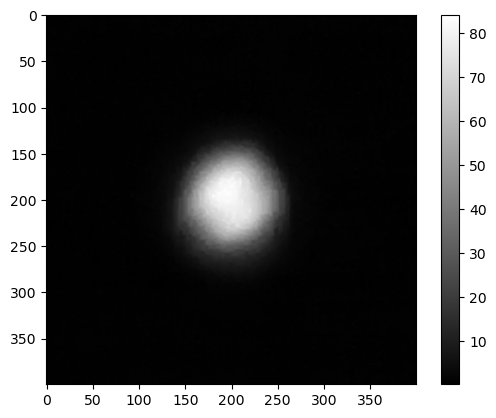

In [4]:
picam2.camera_controls['ScalerCrop']
max_crop = picam2.camera_properties["ScalerCropMaximum"]

picam2.stop()

width = 800

#Set crop region: (x, y, width, height)
camera_config["main"]["size"] = (int(width//2), int(width//2))
picam2.configure(camera_config)

print(x_cen, y_cen)
x = int(y_cen_cal-width/2)
y = int(x_cen_cal-width/2)
w = int(width)
h = int(width)
# Apply the crop
picam2.set_controls({"ScalerCrop": (x, y, w, h)})

picam2.start()

plt.figure()
data=picam2.capture_array()
data = data[..., :3] @ [0.2989, 0.5870, 0.1140]
plt.imshow(data, cmap='gray')
plt.colorbar()
plt.show()

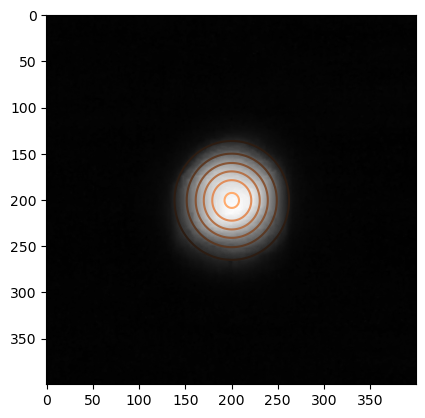

200.51515784148467 200.165863787338


In [5]:
#mirror spacing
x1 = 0.155
x2 = 0.27
x3 = 0.14
x4 = 0.15
#lens spacing
dy0 = 0.36
dy1 = 0.16
#focal length
fl1 = 0.205
fl2 = 0.145
fl3 = 1
#MOT and Cavity
MOT_pos_1=0
Cav_pos_1=0

MOT_pos_2=0
Cav_pos_2=0

MOT_pos_rel = 0.195
MOT_Cav_dist = -0.044

params={'x1':x1, 'x2':x2, 'x3': x3, 'x4':x4, 'dy0':dy0, 'dy1':dy1, 'fl1': fl1, 'fl2': fl2, 'fl3': fl3, 'MOT_pos_rel': MOT_pos_rel, 'MOT_Cav_dist': MOT_Cav_dist, 'MOT_pos_1': MOT_pos_1, 'Cav_pos_1': Cav_pos_1, 'MOT_pos_2': MOT_pos_2, 'Cav_pos_2': Cav_pos_2}

knob_deg_list=angle_calc_single(params)
servos.set_angle(knob_deg_list)

data=picam2.capture_array()
data = data[..., :3] @ [0.2989, 0.5870, 0.1140]
params_g = fitgaussian(data)
fit = gaussian(*params_g)

plt.figure()
plt.imshow(data, cmap=plt.cm.gray)
plt.contour(fit(*np.indices(data.shape)), cmap=plt.cm.copper)

plt.show()

(height, x_cen, y_cen, width_x, width_y) = params_g

print(x_cen, y_cen)

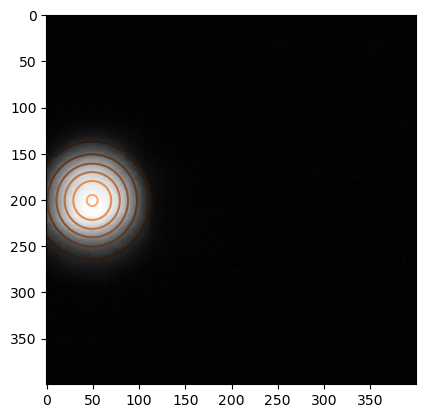

200.55396534437025 49.172010110204354


In [25]:
#mirror spacing
x1 = 0.155
x2 = 0.27
x3 = 0.14
x4 = 0.15
#lens spacing
dy0 = 0.36
dy1 = 0.16
#focal length
fl1 = 0.205
fl2 = 0.145
fl3 = 1
#MOT and Cavity
MOT_pos_1=3e-4
Cav_pos_1=0

MOT_pos_2=0
Cav_pos_2=0

MOT_pos_rel = 0.17
MOT_Cav_dist = -0.044

params={'x1':x1, 'x2':x2, 'x3': x3, 'x4':x4, 'dy0':dy0, 'dy1':dy1, 'fl1': fl1, 'fl2': fl2, 'fl3': fl3, 'MOT_pos_rel': MOT_pos_rel, 'MOT_Cav_dist': MOT_Cav_dist, 'MOT_pos_1': MOT_pos_1, 'Cav_pos_1': Cav_pos_1, 'MOT_pos_2': MOT_pos_2, 'Cav_pos_2': Cav_pos_2}

knob_deg_list=angle_calc_single(params)
servos.set_angle(knob_deg_list)

data=picam2.capture_array()
data = data[..., :3] @ [0.2989, 0.5870, 0.1140]
params_g = fitgaussian(data)
fit = gaussian(*params_g)

plt.figure()
plt.imshow(data, cmap=plt.cm.gray)
plt.contour(fit(*np.indices(data.shape)), cmap=plt.cm.copper)

plt.show()

(height, x_cen, y_cen, width_x, width_y) = params_g

print(x_cen, y_cen)

In [29]:
#mirror spacing
x1 = 0.155
x2 = 0.27
x3 = 0.14
x4 = 0.15
#lens spacing
dy0 = 0.36
dy1 = 0.16
#focal length
fl1 = 0.205
fl2 = 0.145
fl3 = 1
#MOT and Cavity
MOT_pos_1=0
Cav_pos_1=0

MOT_pos_2=0
Cav_pos_2=0

MOT_pos_rel = 0.20
MOT_Cav_dist = -0.044

In [30]:
solver_0=Optical_system_solver()
#scan_xr=scan_xarray_gen(var_str_list=['fl1','fl2','MOT_pos_1','MOT_pos_2'], range_list=[1e-2, 1e-2, 2e-4, 2e-4], num_list=[5,5,10,10], start_value_list=[fl1, MOT_pos_1, MOT_pos_2])
#scan_xr=scan_xarray_gen(solver_0, var_str_list=['fl1','MOT_pos_rel','Cav_pos_1'], range_list=[1e-2, 4e-2, 4e-4], num_list=[5,20,20], start_value_list=[fl1, MOT_pos_rel, Cav_pos_1], params=params)
#scan_xr=scan_xarray_gen(solver_0, var_str_list=['MOT_pos_rel','Cav_pos_2'], range_list=[4e-2, 4e-4], num_list=[20,20], start_value_list=[MOT_pos_rel, Cav_pos_2], params=params)
#scan_xr=scan_xarray_gen(solver_0, var_str_list=['MOT_pos_rel','Cav_pos_1','Cav_pos_2'], range_list=[2e-2, 4e-4, 4e-4], num_list=[10,20,20], start_value_list=[MOT_pos_rel , Cav_pos_1, Cav_pos_2], params=params)
scan_xr=scan_xarray_gen(solver_0, var_str_list=['MOT_pos_rel','MOT_pos_1','MOT_pos_2'], range_list=[2e-2, 3e-4, 3e-4], num_list=[10,20,20], start_value_list=[MOT_pos_rel , MOT_pos_1, MOT_pos_2], params=params)
#scan_xr=scan_xarray_gen(solver_0, var_str_list=['fl1','fl2','Cav_pos_1','Cav_pos_2'], range_list=[1e-2, 1e-2, 4e-4, 4e-4], num_list=[5,5,10,10], start_value_list=[fl1, fl2, Cav_pos_1, Cav_pos_2], params=params)
#scan_xr=scan_xarray_gen(solver_0, var_str_list=['dy0','MOT_pos_rel','Cav_pos_1','Cav_pos_2'], range_list=[2e-2, 2e-2, 4e-4, 4e-4], num_list=[5,5,10,10], start_value_list=[dy0,MOT_pos_rel,Cav_pos_1, Cav_pos_2], params=params)
scan_xr

100%|██████████| 4000/4000 [00:15<00:00, 253.33it/s]


<xarray.DataArray (MOT_pos_rel: 10, MOT_pos_1: 20, MOT_pos_2: 20, knobs: 8)>
array([[[[ 268.53633293,  233.85580843,  322.23882936, ...,
           -64.70977567,   68.34101833,  -44.04441146],
         [ 264.40438676,  209.20779603,  318.10683833, ...,
           -57.89972627,   65.57923268,  -39.40681054],
         [ 260.27356571,  184.56743879,  313.97597255, ...,
           -51.08929287,   62.81831367,  -34.76953288],
         ...,
         [ 198.43693485, -184.17860209,  252.1387047 , ...,
            51.10725696,   21.50842055,   34.7515685 ],
         [ 194.32224349, -208.70834194,  248.02397364, ...,
            57.92280099,   18.76189757,   39.38373611],
         [ 190.20844417, -233.23190262,  243.91013507, ...,
            64.73860252,   16.01647169,   44.01558713]],

        [[ 244.41755673,  233.85580843,  292.46690019, ...,
           -64.70977567,   63.90204881,  -44.04441146],
         [ 240.28495241,  209.20779603,  288.33425797, ...,
           -57.89972627,   61.14046501,  -39.40681054],
         [ 236.15347326,  184.56743879,  284.20274113, ...,
           -51.08929287,   58.37974429,  -34.76953288],
...
         [-223.45114385, -173.91132975, -243.6456493 , ...,
           -18.5329773 , -107.19111039,   70.16659389],
         [-227.12510636, -197.07760698, -247.31962148, ...,
           -21.00214243, -109.63697349,   79.52022059],
         [-230.79837852, -220.23889315, -250.99290305, ...,
           -23.47086899, -112.08230366,   88.87339493]],

        [[-183.9359333 ,  220.72911307, -206.5061439 , ...,
            23.51063571,  -75.96424446,  -88.91315918],
         [-187.62344048,  197.47004603, -210.19366347, ...,
            21.03397584,  -78.41715841,  -79.55205342],
         [-191.31012109,  174.21685574, -213.88035648, ...,
            18.55776057,  -80.86902337,  -70.19137719],
         ...,
         [-246.51659228, -173.91132975, -269.0870028 , ...,
           -18.5329773 , -117.64531741,   70.16659389],
         [-250.19114194, -197.07760698, -272.76156237, ...,
           -21.00214243, -120.09123728,   79.52022059],
         [-253.86500118, -220.23889315, -276.43543107, ...,
           -23.47086899, -122.53662462,   88.87339493]]]])
Coordinates:
  * MOT_pos_rel  (MOT_pos_rel) float64 0.18 0.1844 0.1889 ... 0.2111 0.2156 0.22
  * MOT_pos_1    (MOT_pos_1) float64 -0.0003 -0.0002684 ... 0.0002684 0.0003
  * MOT_pos_2    (MOT_pos_2) float64 -0.0003 -0.0002684 ... 0.0002684 0.0003
  * knobs        (knobs) <U6 'Mrr1_x' 'Mrr1_y' 'Mrr2_x' ... 'Mrr4_x' 'Mrr4_y'

In [31]:
ds=iteration_actuator(servos, picam2, scan_xr)
ds
ds.to_netcdf("data0308_3.nc")

100%|██████████| 4000/4000 [2:39:20<00:00,  2.39s/it]  
2025-03-08 23:25:10,112 - INFO - going home


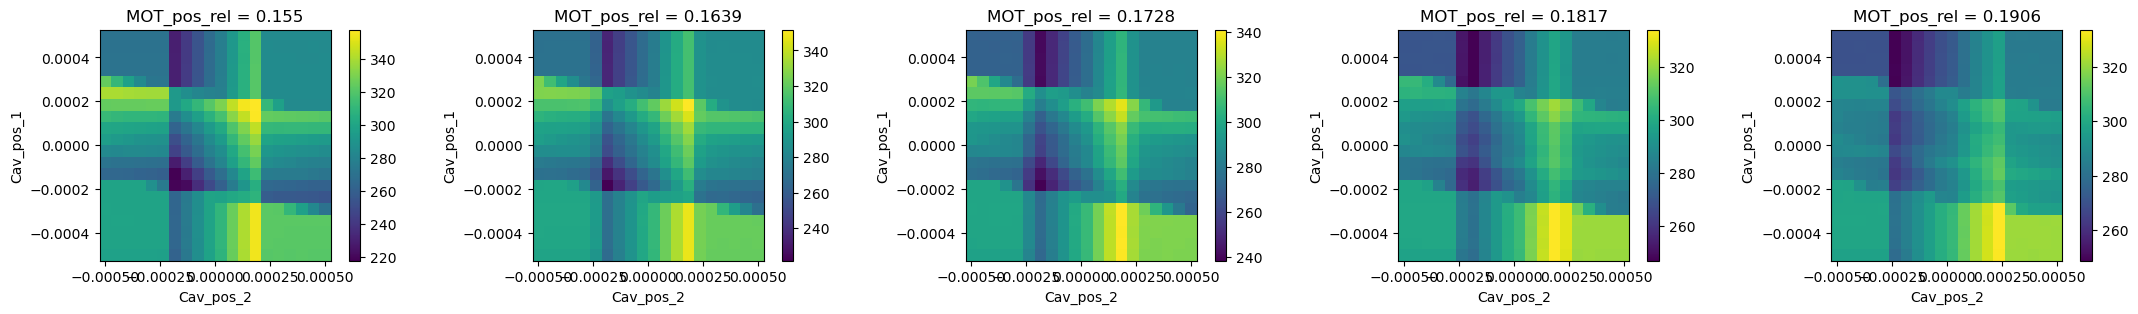

In [8]:
da=np.sqrt(ds['cam_pos_x']**2+ds['cam_pos_y']**2)

fig,axs=plt.subplots(1,5,figsize=(27,3)) 
for i in range(5):
    da.isel(MOT_pos_rel=i).plot(ax=axs[i])
    axs[i].set_aspect('equal')
#fig.tight_layout()
plt.show()

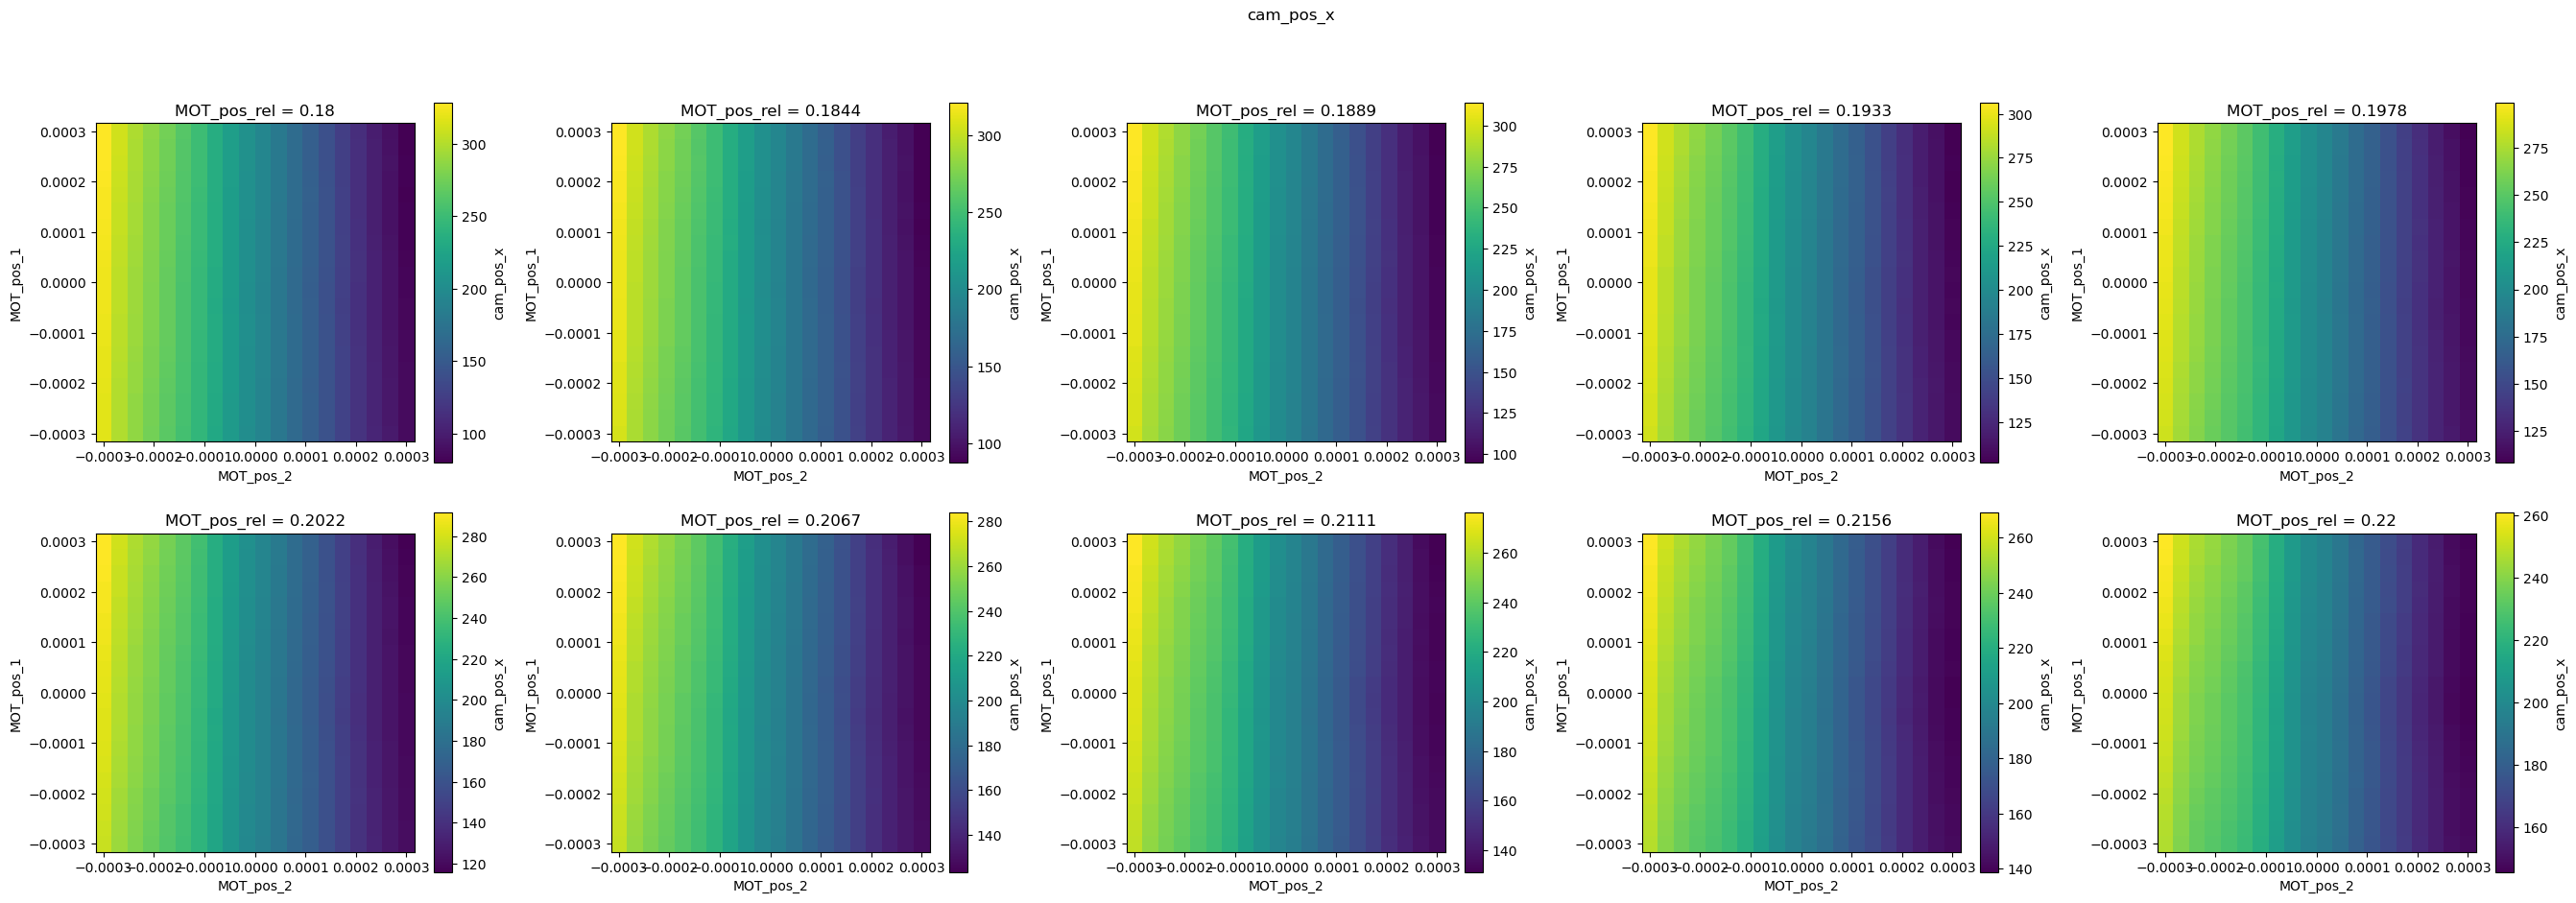

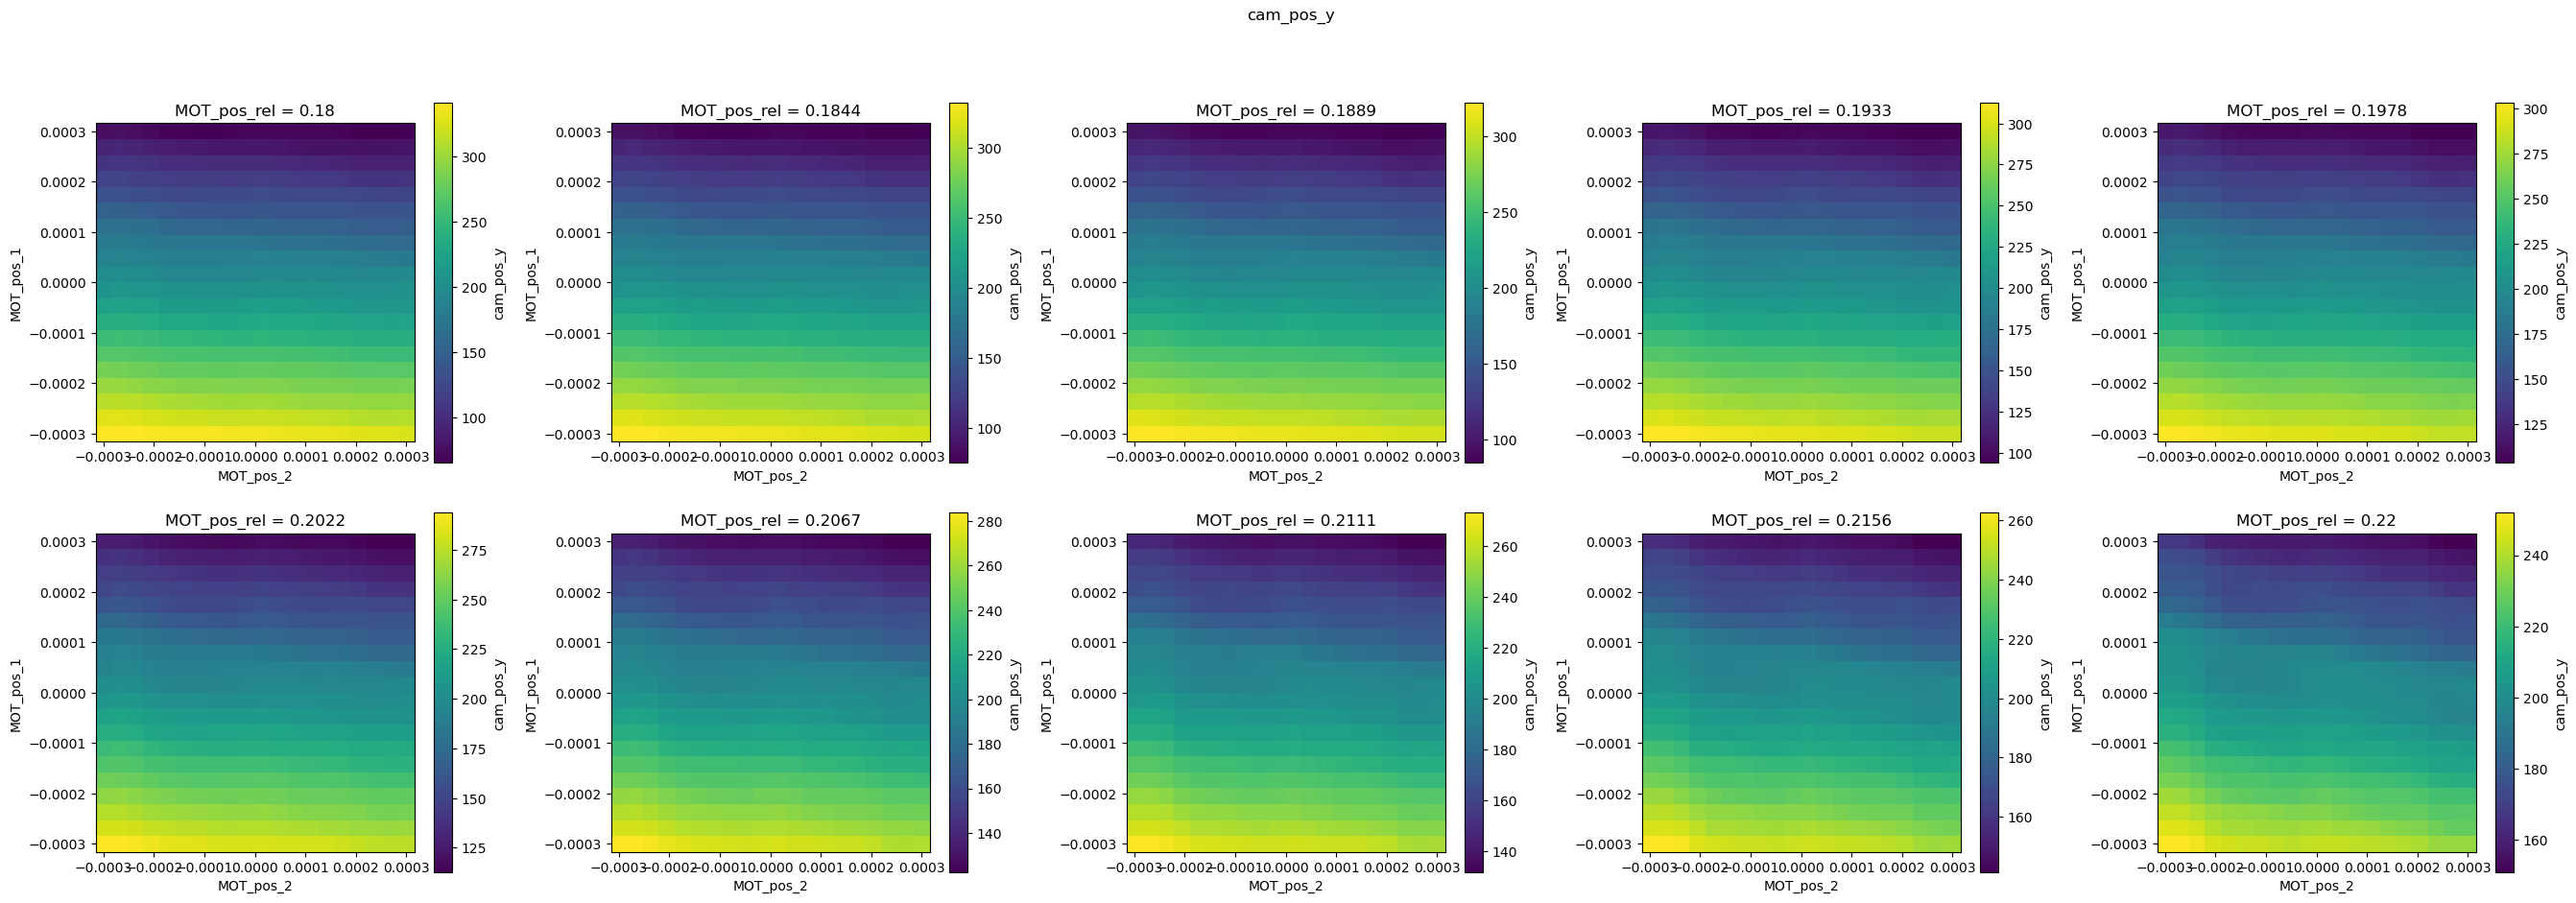

In [54]:
fig,axs=plt.subplots(2,5,figsize=(27,9)) 
for i in range(10):
    fig.suptitle('cam_pos_x', y=1.05)
    ds['cam_pos_x'].isel(MOT_pos_rel=i).plot(ax=axs[i//5,i%5])
    axs[i//5,i%5].set_aspect('equal')
fig.tight_layout()
plt.show()

fig,axs=plt.subplots(2,5,figsize=(27,9)) 
for i in range(10):
    fig.suptitle('cam_pos_y', y=1.05)
    ds['cam_pos_y'].isel(MOT_pos_rel=i).plot(ax=axs[i//5,i%5])
    axs[i//5,i%5].set_aspect('equal')
fig.tight_layout()
plt.show()

In [11]:
ds_0=xr.open_dataset("data0308_2.nc")-200
ds_1=xr.open_dataset("data0308_3.nc")-200

ds_0m=ds_0.assign_coords({'Cav_pos_1':ds_0.coords['Cav_pos_1'].values*1e6}).assign_coords({'Cav_pos_2':ds_0.coords['Cav_pos_2'].values*1e6}).assign_coords({'MOT_pos_rel':ds_0.coords['MOT_pos_rel'].values*1e2})
ds_1m=ds_1.assign_coords({'MOT_pos_1':ds_1.coords['MOT_pos_1'].values*1e6}).assign_coords({'MOT_pos_2':ds_1.coords['MOT_pos_2'].values*1e6}).assign_coords({'MOT_pos_rel':ds_1.coords['MOT_pos_rel'].values*1e2})

ds_1m_r=ds_1m*1.55*2

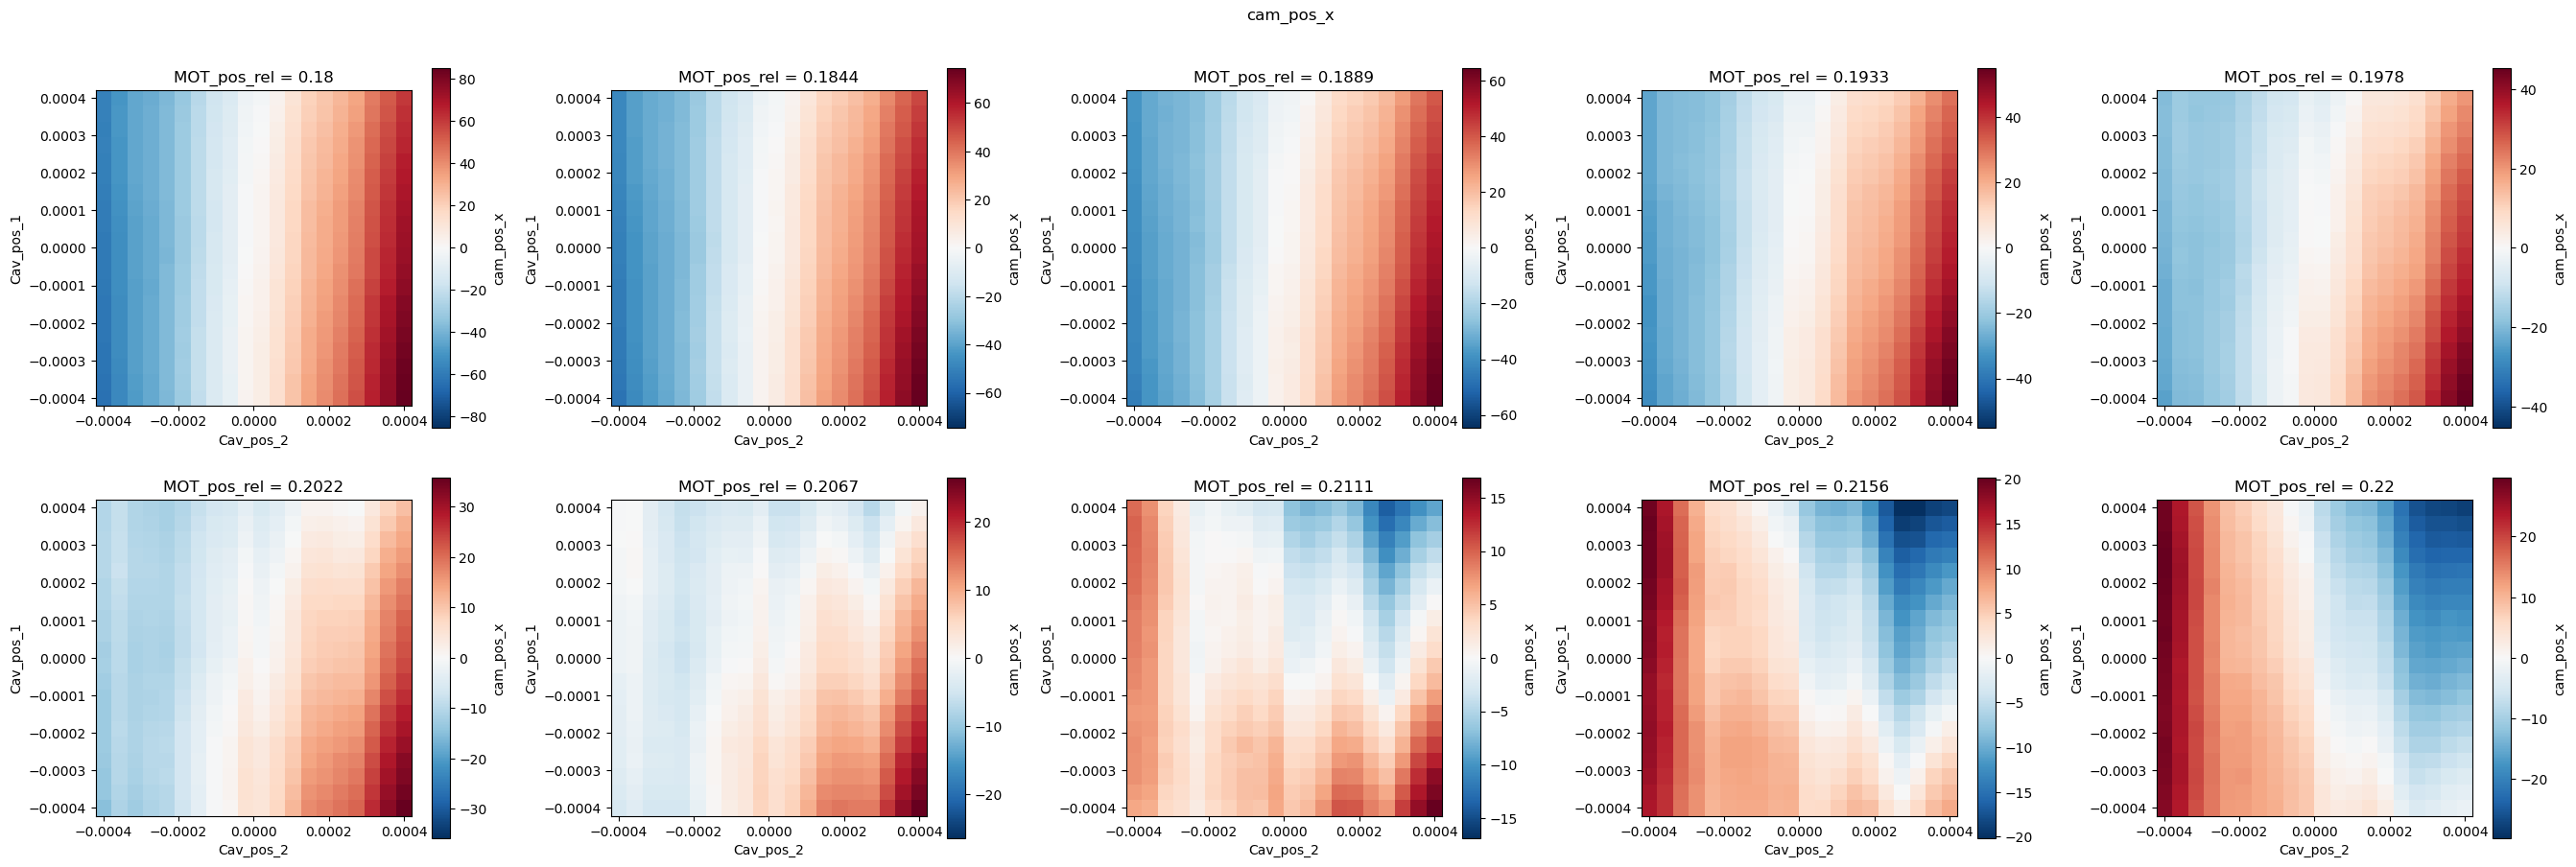

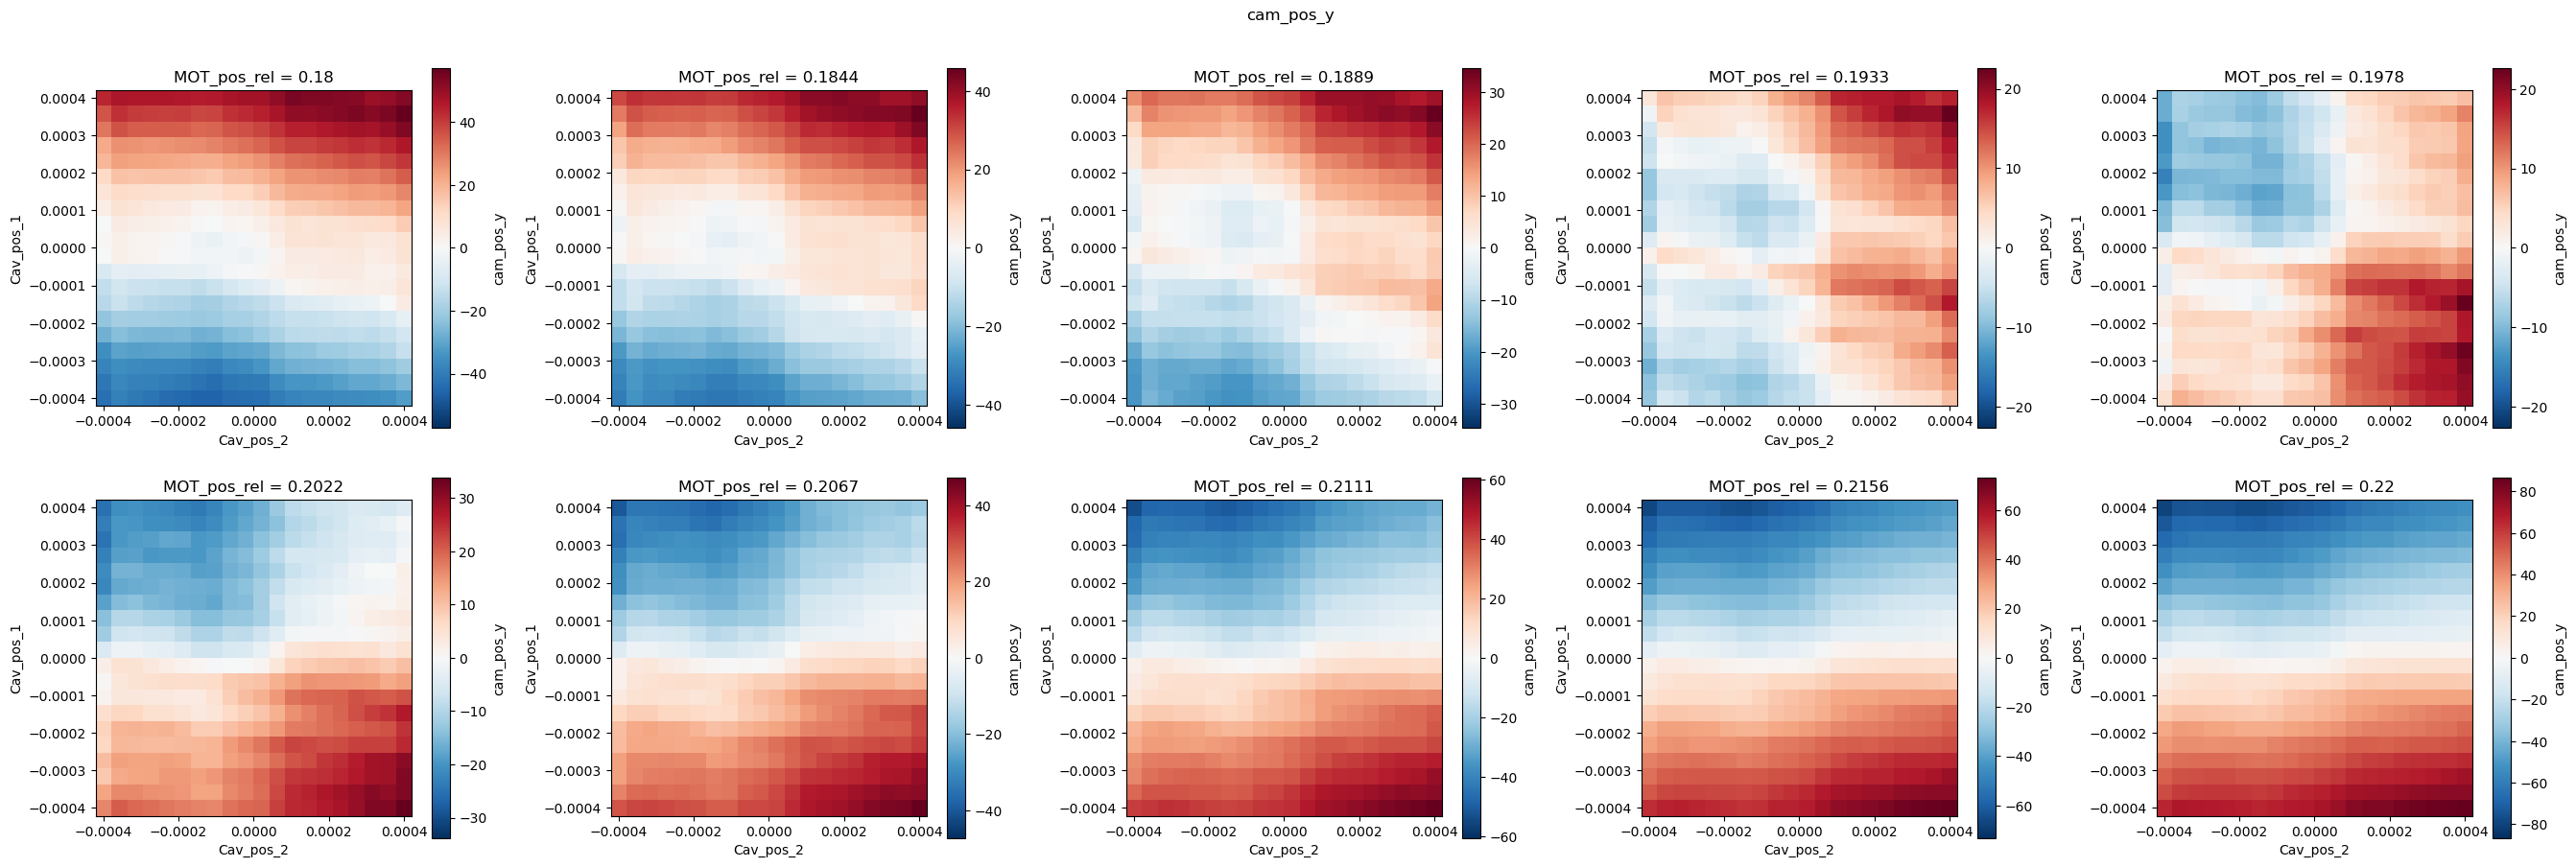

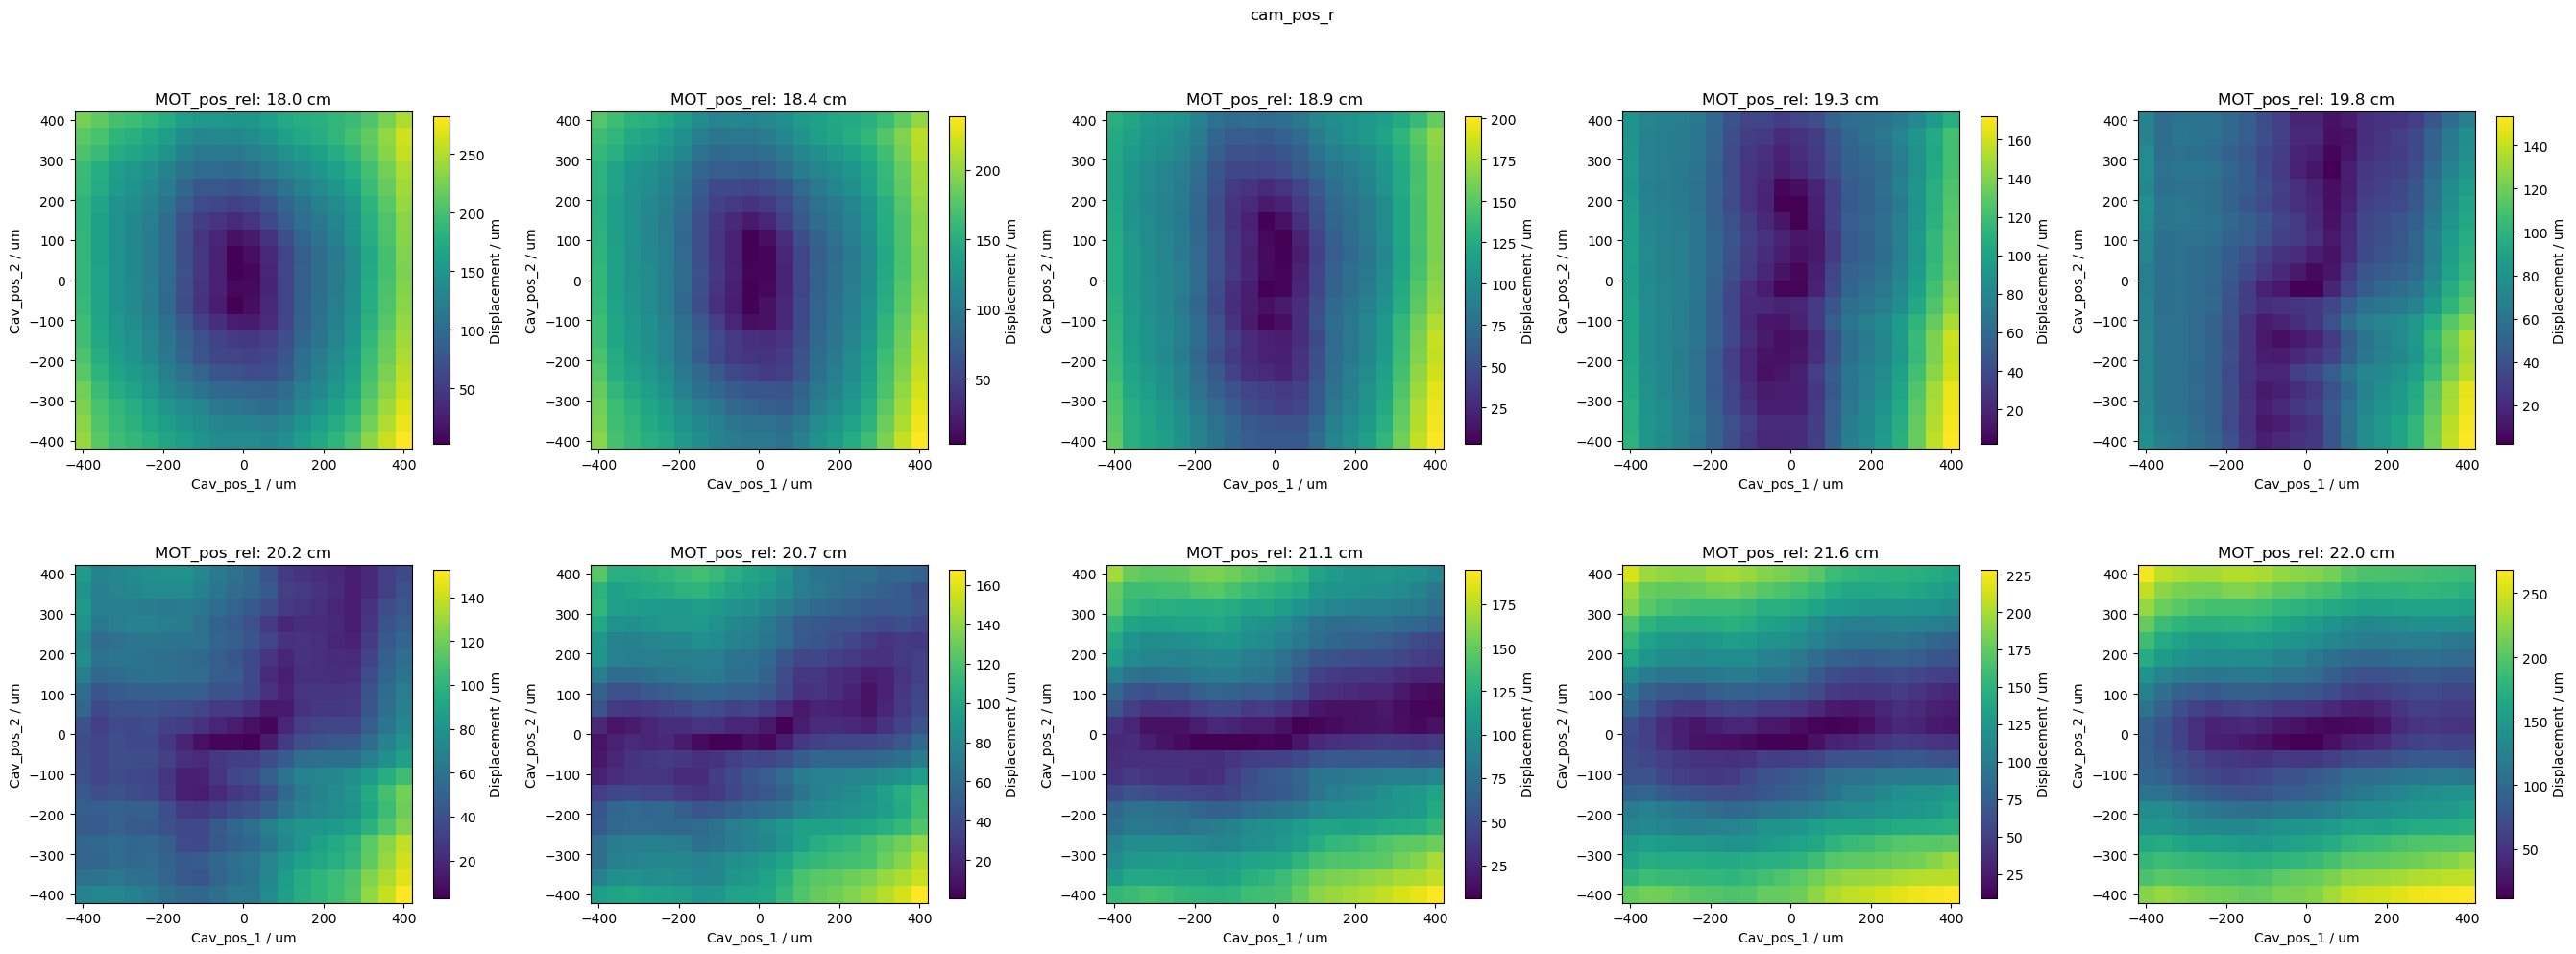

In [ ]:
ds_0m_r=np.sqrt(ds_0m['cam_pos_x']**2+ds_0m['cam_pos_y']**2)*1.55*2

fig,axs=plt.subplots(2,5,figsize=(27,9)) 
for i in range(10):
    fig.suptitle('cam_pos_x', y=1.01)
    ds_0['cam_pos_x'].isel(MOT_pos_rel=i).plot(ax=axs[i//5,i%5])
    axs[i//5,i%5].set_aspect('equal')
fig.tight_layout()
plt.show()

fig,axs=plt.subplots(2,5,figsize=(27,9)) 
for i in range(10):
    fig.suptitle('cam_pos_y', y=1.01)
    ds_0['cam_pos_y'].isel(MOT_pos_rel=i).plot(ax=axs[i//5,i%5])
    axs[i//5,i%5].set_aspect('equal')
fig.tight_layout()
plt.show()

fig,axs=plt.subplots(2,5,figsize=(27,10)) 
for i in range(10):
    fig.suptitle('cam_pos_r', y=1.01)
    ds_0m_r.isel(MOT_pos_rel=i).plot(ax=axs[i//5,i%5],cbar_kwargs={'label': "Displacement / um", 'shrink': 0.75})
    axs[i//5,i%5].set_aspect('equal')
    axs[i//5,i%5].set_title('MOT_pos_rel: '+str(np.round(ds_0m_r.coords['MOT_pos_rel'].values[i],1))+' cm')
    axs[i//5,i%5].set_xlabel('Cav_pos_1 / um')
    axs[i//5,i%5].set_ylabel('Cav_pos_2 / um')
fig.tight_layout()
plt.show()

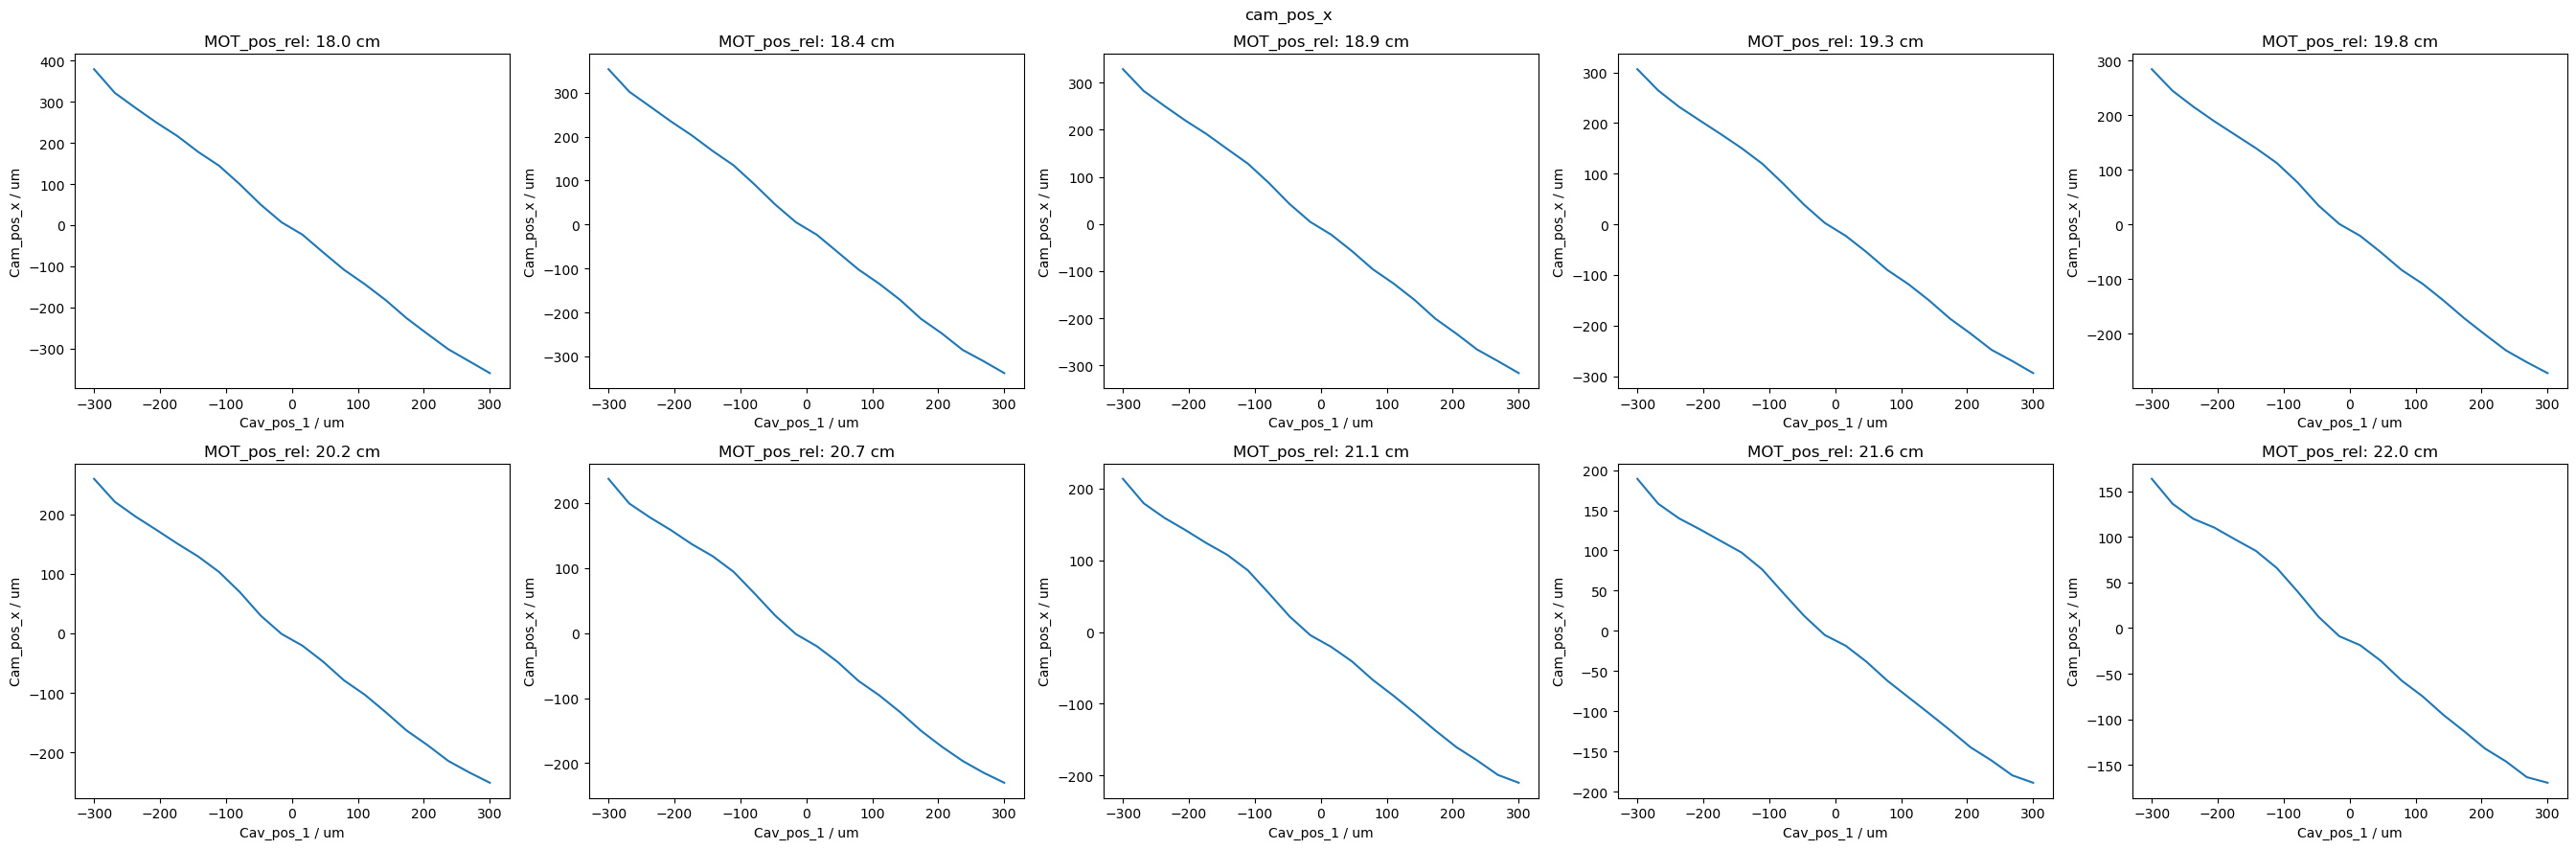

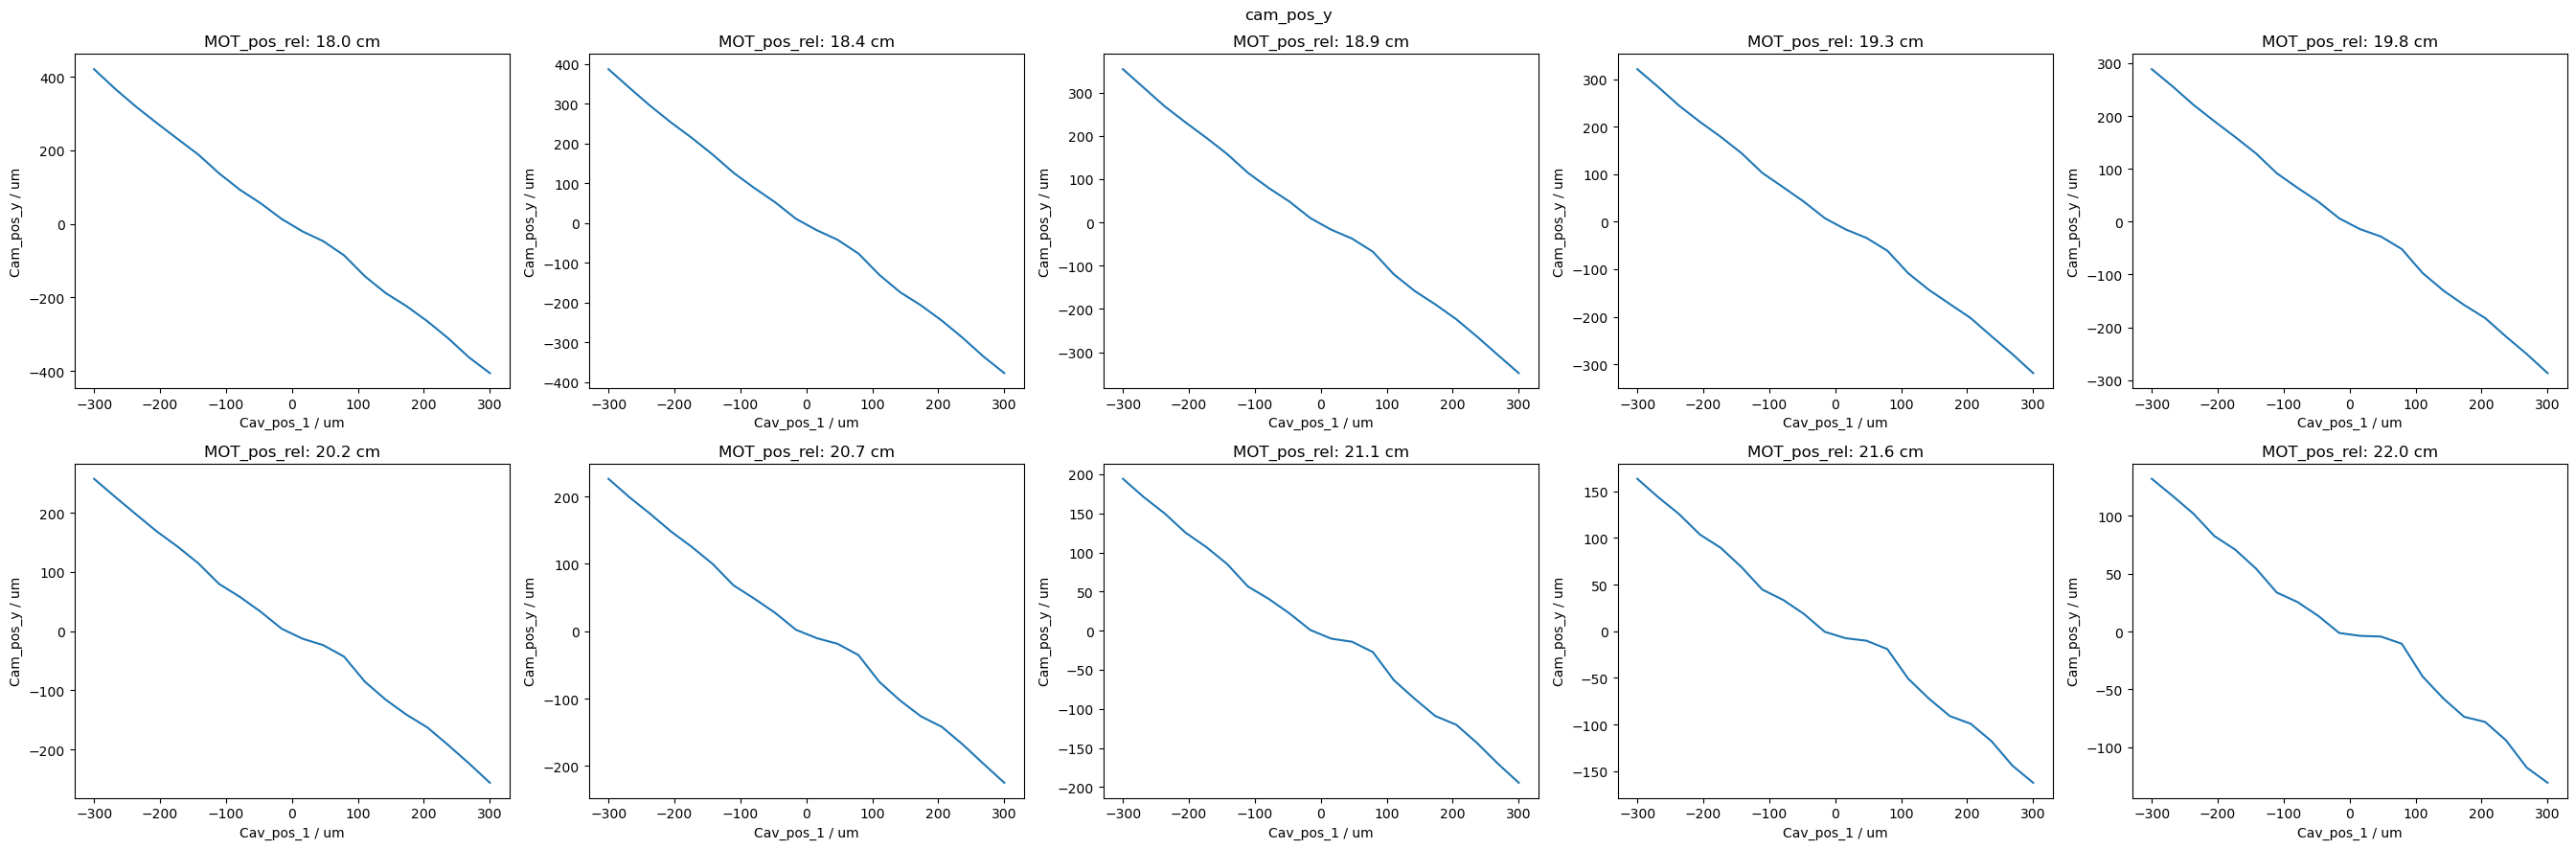

In [ ]:
fig,axs=plt.subplots(2,5,figsize=(27,9)) 
for i in range(10):
    fig.suptitle('cam_pos_x')
    #ds_1m_r['cam_pos_x'].mean(dim='MOT_pos_1').isel(MOT_pos_rel=i).plot(ax=axs[i//5,i%5])
    ds_1m_r['cam_pos_x'].isel(MOT_pos_1=9).isel(MOT_pos_rel=i).plot(ax=axs[i//5,i%5])
    axs[i//5,i%5].set_title('MOT_pos_rel: '+str(np.round(ds_1m_r.coords['MOT_pos_rel'].values[i],1))+' cm')
    axs[i//5,i%5].set_xlabel('Cav_pos_1 / um')
    axs[i//5,i%5].set_ylabel('Cam_pos_x / um')

fig.tight_layout()
plt.show()

fig,axs=plt.subplots(2,5,figsize=(27,9)) 
for i in range(10):
    fig.suptitle('cam_pos_y')
    #ds_1m_r['cam_pos_y'].mean(dim='MOT_pos_2').isel(MOT_pos_rel=i).plot(ax=axs[i//5,i%5])
    ds_1m_r['cam_pos_y'].isel(MOT_pos_2=9).isel(MOT_pos_rel=i).plot(ax=axs[i//5,i%5])
    axs[i//5,i%5].set_title('MOT_pos_rel: '+str(np.round(ds_1m_r.coords['MOT_pos_rel'].values[i],1))+' cm')
    axs[i//5,i%5].set_xlabel('Cav_pos_1 / um')
    axs[i//5,i%5].set_ylabel('Cam_pos_y / um')
fig.tight_layout()
plt.show()

In [36]:
servos.home()

2025-03-08 11:35:14,963 - INFO - going home


In [5]:
picam2.stop()

2025-03-07 16:51:20,165 - INFO - Camera stopped
